In [278]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as datetime
import scipy.stats as stats
import lightgbm as lgb
import shap
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

In [279]:
pd.set_option('display.max_columns', None)

In [280]:
df = pd.read_csv('/content/nigeria_merchant_risk_clean.csv')
df.head(2)

,txn_ref,merchant_ref,txn_datetime,amount_ngn,business_sector,mcc_code,merchant_country,onboarded_last_30d,channel,dispute_outcome,legacy_risk_score,confirmed_fraud
0,TXN-0000001,NGM-87116C,2025-01-01 00:04:17,65174.92,Logistics,5100,SN,No,Instant Transfer,No Dispute,43.0,0
1,TXN-0000002,NGM-01643F,2025-01-01 00:37:55,13987.87,Supermarkets,4030,GH,No,POS Terminal,No Dispute,33.0,0


**Data Audit**

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350000 entries, 0 to 349999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   txn_ref             350000 non-null  object 
 1   merchant_ref        350000 non-null  object 
 2   txn_datetime        350000 non-null  object 
 3   amount_ngn          350000 non-null  float64
 4   business_sector     350000 non-null  object 
 5   mcc_code            350000 non-null  int64  
 6   merchant_country    350000 non-null  object 
 7   onboarded_last_30d  350000 non-null  object 
 8   channel             350000 non-null  object 
 9   dispute_outcome     350000 non-null  object 
 10  legacy_risk_score   350000 non-null  float64
 11  confirmed_fraud     350000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 32.0+ MB


In [282]:
df.describe().style.format("{:,.2f}")

,amount_ngn,mcc_code,legacy_risk_score,confirmed_fraud
count,"350,000.00","350,000.00","350,000.00","350,000.00"
mean,"52,649.21","4,444.21",19.68,0.02
std,"146,008.11",358.23,12.50,0.14
min,39.42,"4,000.00",8.00,0.00
25%,"7,040.53","4,136.00",8.00,0.00
50%,"18,164.99","4,339.00",18.00,0.00
75%,"48,350.10","4,703.00",26.00,0.00
max,"27,080,000.00","5,378.00",100.00,1.00


In [283]:
df.describe(include="object")

,txn_ref,merchant_ref,txn_datetime,business_sector,merchant_country,onboarded_last_30d,channel,dispute_outcome
count,350000,350000,350000,350000,350000,350000,350000,350000
unique,350000,35000,347158,14,10,2,3,3
top,TXN-0349984,NGM-F272A7,2025-11-18 14:07:44,Supermarkets,NG,No,POS Terminal,No Dispute
freq,1,316,3,55218,181774,329077,187913,342068


In [284]:
df.isna().sum()

,0
txn_ref,0
merchant_ref,0
txn_datetime,0
amount_ngn,0
business_sector,0
mcc_code,0
merchant_country,0
onboarded_last_30d,0
channel,0
dispute_outcome,0


In [285]:
df.duplicated().sum()

np.int64(0)

In [286]:
df.duplicated(["merchant_ref","txn_datetime","amount_ngn"]).sum()

np.int64(0)

**Target analysis**

In [287]:
# fraud rate
fraud_rate = df["confirmed_fraud"].value_counts(normalize=True).rename("class_proportion")
fraud_rate = pd.DataFrame(fraud_rate).rename(index=({0:"Not Fraud", 1:"Fraud"}))
fraud_rate["class_percent"] = fraud_rate *100
fraud_rate

,class_proportion,class_percent
confirmed_fraud,,
Not Fraud,0.979974,97.997429
Fraud,0.020026,2.002571


Dataset is highly imbalance with ~2% of fraudulent transactions.

In [288]:
# Count unique fraud labels (0, 1, or both) per merchant
fraud_rate_merchant = df.groupby("merchant_ref")["confirmed_fraud"].nunique()
fraud_rate_merchant.sort_values(ascending=False)


,confirmed_fraud
merchant_ref,
NGM-EAE827,2
NGM-0B05F3,2
NGM-E5DF77,2
NGM-468577,2
NGM-70EAC8,2
...,...
NGM-550E1B,1
NGM-551073,1
NGM-551289,1


In [289]:
merchant_id = "NGM-EAE827" #"NGM-897F82"
df_1_merchant = df[df["merchant_ref"] == merchant_id]
print(f"Analysing Merchant: {merchant_id}")
print(f"_"*30,"\n")
print(f"Total Transaction: {len(df_1_merchant)}\n")
print(f"Fraud per transaction breakdown:")
df_1_merchant["confirmed_fraud"].value_counts()
#

Analysing Merchant: NGM-EAE827
______________________________ 

Total Transaction: 12

Fraud per transaction breakdown:


,count
confirmed_fraud,
1,10
0,2


Fraud label is not unique per merchant but per transactions.

It appears that the label is at the transaction level, not the merchant level, but the task is to predict a fraudulent/fraud merchant. So, what is a "fraud merchant"?
This is a business modeling decision. There are several possible routes for deriving a merchant-level label:

- **At least one flag**: A merchant with at least one fraudulent transaction is classified as a "Fraud Merchant."
- **Minimum count `k`**: A merchant with a minimum fraudulent transaction count of `k` (e.g., `k`) is classified as a "Fraud Merchant."
- **Fraud ratio threshold**: A merchant whose fraudulent transactions exceed a specific share of their total volume (e.g., `20%`) is classified as a "Fraud Merchant."


Each of these options carries distinct trade-offs. All three strategies will be tested using a time-windowed framework, where the dataset is partitioned into an observation window (for feature engineering and model training) and a prediction window (for target labeling). This separation ensures that the labels are not derived from the same temporal data used to generate predictions, effectively preventing target leakage.

In [290]:
df.groupby("merchant_ref")["confirmed_fraud"].agg(["mean","count"]).sort_values(by="count", ascending=False)

,mean,count
merchant_ref,,
NGM-F272A7,0.000000,316
NGM-28840A,0.723881,268
NGM-6C34A0,0.000000,233
NGM-695BA6,0.000000,207
NGM-D40057,0.695652,207
...,...,...
NGM-724783,0.000000,1
NGM-87A37C,0.000000,1
NGM-501362,0.000000,1


Fraud rate and volume varies widely across merchants.

- High-Volume, clean merchants like NGM-F272A7 have processed over 316 transactions with a 0% fraud rate.

- High-Volume merchants  with high fraud transactions like NGM-28840A (268 transactions, 72.4% fraud rate) and NGM-D40057 (207 transactions, 69.6% fraud rate) are under active velocity attacks or represent compromised burner merchant accounts setup to drain cards.

- Thousands of merchants with a volume of exactly 1 transaction and a 0% fraud rate

In [291]:
# Time Features
df["txn_datetime"] = pd.to_datetime(df["txn_datetime"])
df["txn_date"] = df["txn_datetime"].dt.date # e.g, 2025-08-11
df["txn_dayofweek"] = df["txn_datetime"].dt.dayofweek # 0-Mon, 1-Tue,..., 6-Sun
df["txn_hour"] = df["txn_datetime"].dt.hour #0-23
df["txn_week"] = df["txn_datetime"].dt.isocalendar().week # 1-52
df["txn_month"] = df["txn_datetime"].dt.month # 1-12
df["is_weekend"] = df["txn_dayofweek"].isin([5,6])
df["is_night"] = df["txn_hour"].isin([0,1,2,3,4])
df["is_month_end"] = df["txn_datetime"].dt.is_month_end
df["is_month_start"] = df["txn_datetime"].dt.is_month_start
df[["txn_datetime", "txn_dayofweek",	"txn_hour",	"txn_week",	"txn_month"]].describe()

,txn_datetime,txn_dayofweek,txn_hour,txn_week,txn_month
count,350000,350000.000000,350000.000000,350000.0,350000.000000
mean,2025-07-04 09:19:30.025471232,2.994586,13.463649,26.731217,6.584766
min,2025-01-01 00:04:17,0.000000,0.000000,1.0,1.000000
25%,2025-04-07 22:56:19.249999872,1.000000,11.000000,14.0,4.000000
50%,2025-07-06 13:42:23.500000,3.000000,14.000000,27.0,7.000000
75%,2025-09-28 19:22:03,5.000000,17.000000,39.0,9.000000
max,2025-12-31 23:58:18,6.000000,23.000000,52.0,12.000000
std,NaN,1.997001,4.602678,14.669987,3.362098


In [292]:
df.tail(1)

,txn_ref,merchant_ref,txn_datetime,amount_ngn,business_sector,mcc_code,merchant_country,onboarded_last_30d,channel,dispute_outcome,legacy_risk_score,confirmed_fraud,txn_date,txn_dayofweek,txn_hour,txn_week,txn_month,is_weekend,is_night,is_month_end,is_month_start
349999,TXN-0350000,NGM-472558,2025-12-31 23:58:18,17085.78,Fuel Stations,4112,NG,No,Instant Transfer,No Dispute,18.0,0,2025-12-31,2,23,1,12,False,False,True,False


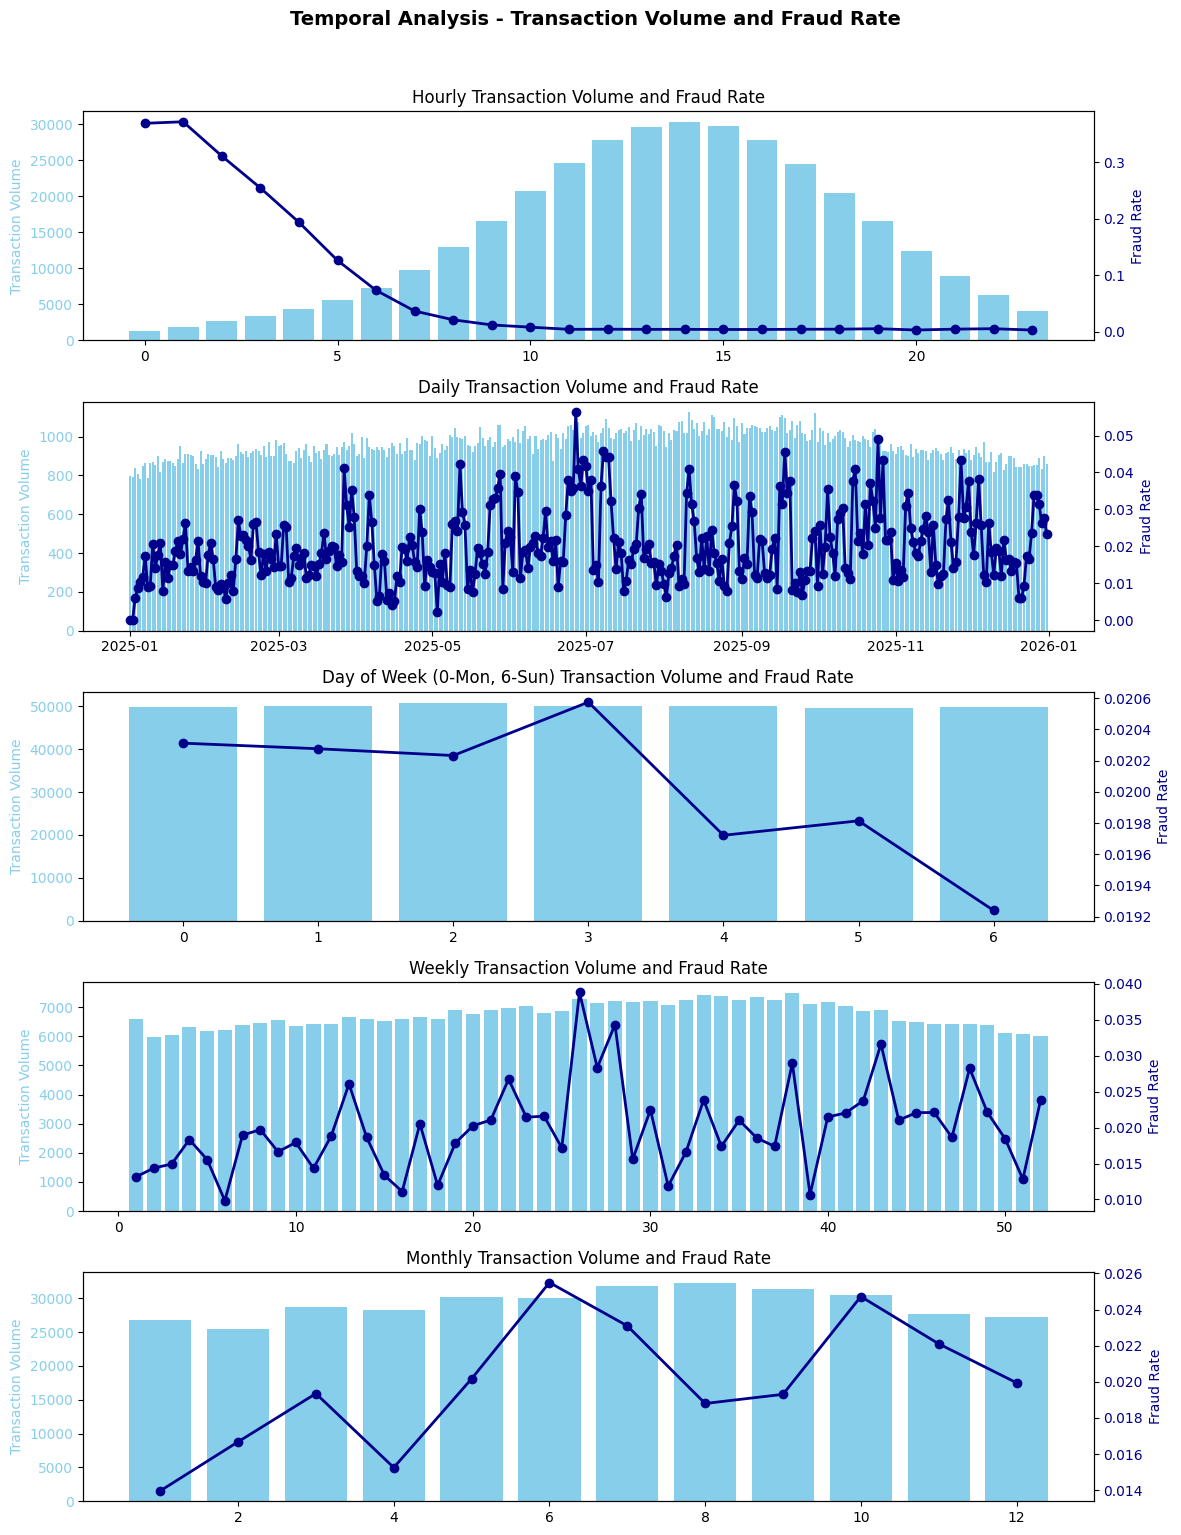

In [293]:
# Fraud rate over time

temporal_summmary= {
    "Hourly": df.groupby("txn_hour")["confirmed_fraud"].agg(total_volume="count", fraud_rate="mean"),
    "Daily": df.groupby("txn_date")["confirmed_fraud"].agg(total_volume="count", fraud_rate="mean"),
    "Day of Week (0-Mon, 6-Sun)": df.groupby("txn_dayofweek")["confirmed_fraud"].agg(total_volume="count", fraud_rate="mean"),
    "Weekly": df.groupby("txn_week")["confirmed_fraud"].agg(total_volume="count", fraud_rate="mean"),
    "Monthly": df.groupby("txn_month")["confirmed_fraud"].agg(total_volume="count", fraud_rate="mean")
}

fig, axes = plt.subplots(5,1, figsize=(12,15))
axes = axes.flatten()

for idx, (title, summary) in enumerate(temporal_summmary.items()):
    ax = axes[idx]
    ax_ = ax.twinx()
    ax.bar(
        summary.index,
        summary["total_volume"],
        color="skyblue",
        label="Total Volume"
    )
    ax.set_ylabel("Transaction Volume", color="skyblue")
    ax.tick_params(axis="y", labelcolor="skyblue")

    ax_.plot(
        summary.index,
        summary["fraud_rate"],
        color="darkblue",
        marker="o",
        linewidth=2,
        label="Fraud Rate"
    )
    ax_.set_ylabel("Fraud Rate", color="darkblue")
    ax_.tick_params(axis="y", labelcolor="darkblue")

    ax.set_title(f"{title} Transaction Volume and Fraud Rate")

plt.suptitle("Temporal Analysis - Transaction Volume and Fraud Rate", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- Fraud rate does not just lean higher at night—it explodes asynchronously. Between hours 0 and 4, fraud rate is at its absolute maximum (over 30%), while transaction volume drops to its absolute lowest point. Volume is not uniform; it follows a clear bimodal consumer distribution peaking around 13:00–15:00.
- The fraud rate peak on Wednesday (Day 3) reaches the highest point of the week (\~2.06%), but it drops sharply to its lowest point on Sunday (Day 6) (\~1.92%).
- Fraud rate peaks in June (Month 6) and drops to its absolute lowest baseline in January (Month 1).

 There are major, volatile fraud spikes scattered across the year (especially around June and October). A standard random train-test split will smear these temporal bursts across both datasets, resulting in severe data leakage. Training, validation, and test datasets chronologically will be partitioned using Out-of-Time (OOT) hard cutoffs to ensure the model learns to generalize across shifting fraud cycles.

 Also, Since hours (0–23), days of the week (0–6), and months (1–12) wrap around structurally, these columns will be transformed using sine and cosine cyclical encodings so your tree splits understand that hour 23 sits directly adjacent to hour 0.

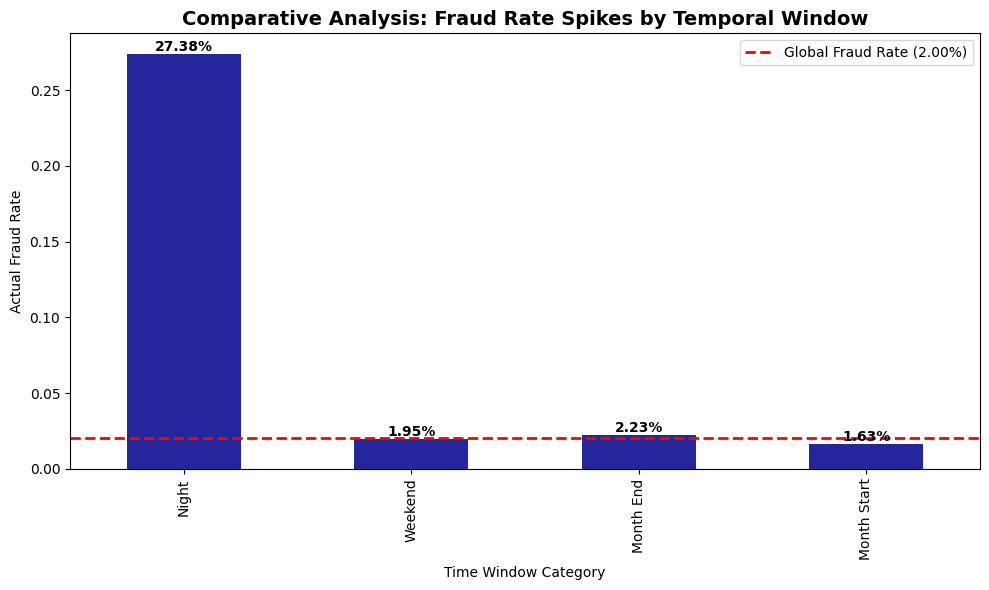

In [294]:
# Investigate night, weekend month end and start bursts

plt.figure(figsize=(10, 6))

global_fraud_rate = df["confirmed_fraud"].value_counts(normalize=True)[1]

time_effect = {
    "Night": df[df["is_night"] == True]["confirmed_fraud"].value_counts(normalize=True)[1],
    "Weekend": df[df["is_weekend"] == True]["confirmed_fraud"].value_counts(normalize=True)[1],
    "Month End": df[df["is_month_end"] == True]["confirmed_fraud"].value_counts(normalize=True)[1],
    "Month Start": df[df["is_month_start"] == True]["confirmed_fraud"].value_counts(normalize=True)[1]
    }

df_rates = pd.Series(time_effect)

ax = df_rates.plot(kind="bar", color="darkblue", alpha=0.85)

plt.axhline(y=global_fraud_rate, color='red', linestyle='--', linewidth=2, label=f'Global Fraud Rate ({global_fraud_rate:.2%})')

plt.title("Comparative Analysis: Fraud Rate Spikes by Temporal Window", fontsize=14, fontweight="bold")
plt.ylabel("Actual Fraud Rate")
plt.xlabel("Time Window Category")
ax.bar_label(ax.containers[0], fmt="{:.2%}", fontsize=10, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

Night Fraud rate analysis confirms very high fraud rate (\~28%) This means that if a transaction occurs at night, it has a 27.4% chance of being fraud.

But the "Fraud" bars drop down to 2.0%, 2.2%, and 1.6% for weekend, month end and month start respectively.Transactions running on weekends or month-ends are no more dangerous than any other day. The features `is_weekend`, `is_month_end`, or `is_month_start` may not contribute significantly to the predictions and can consititute noise, hence should be removed.

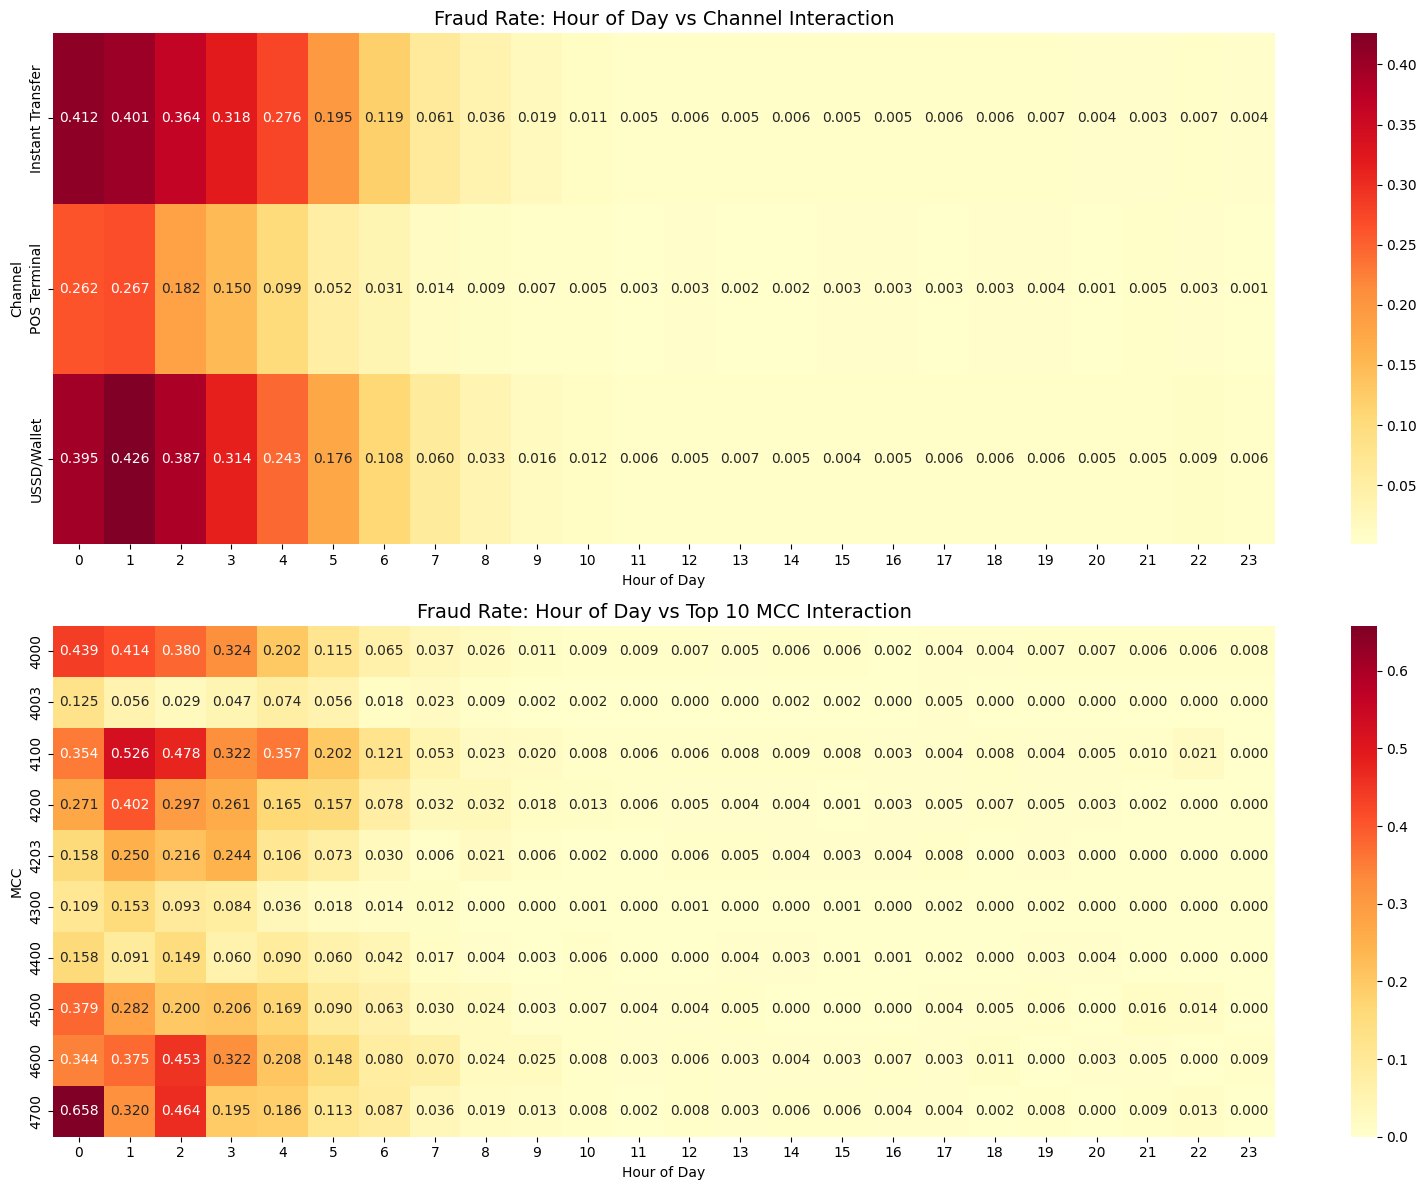

In [295]:
#  Interaction between Hour and channel & Top 10 MCCs
pivot_payment = df.pivot_table(
    values="confirmed_fraud",
    index="channel",
    columns="txn_hour",
    aggfunc="mean"
)

top_mccs = df["mcc_code"].value_counts().nlargest(10).index
df_top_mcc = df[df["mcc_code"].isin(top_mccs)]

pivot_mcc = df_top_mcc.pivot_table(
    values="confirmed_fraud",
    index="mcc_code",
    columns="txn_hour",
    aggfunc="mean"
)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.heatmap(pivot_payment, cmap="YlOrRd", annot=True, fmt=".3f", ax=axes[0])
axes[0].set_title("Fraud Rate: Hour of Day vs Channel Interaction", fontsize=14)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Channel")

sns.heatmap(pivot_mcc, cmap="YlOrRd", annot=True, fmt=".3f", ax=axes[1])
axes[1].set_title("Fraud Rate: Hour of Day vs Top 10 MCC Interaction", fontsize=14)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("MCC")

plt.tight_layout()
plt.show()


The "night effect" is a highly targeted exploitation window rather than a uniform increase in risk across the network.

Instant Transfer and USSD/Wallet channels experience catastrophic fraud acceleration overnight, peaking at 41.2% (Hour 0) and 42.6% (Hour 1) respectively. Fraudsters favor digital channels with immediate clearance pipelines.
Fraud is concentrated within three primary Merchant Category Codes;MCC 4700, MCC 4100 & MCC 4600

**`dispute_outcome`** Analysis

`dispute_outcome` is a potential target leak.

A dispute outcome only exists days or weeks after the transaction, so it should stay out of any real-time model. It is retained in the raw data EDA and for model investigation.

In [296]:
dispute_fraud_rate = pd.crosstab(df.dispute_outcome, df.confirmed_fraud, margins=True)
dispute_fraud_rate["fraud_rate"] = dispute_fraud_rate[1] / dispute_fraud_rate.loc["All", 1]
dispute_fraud_rate

confirmed_fraud,0,1,All,fraud_rate
dispute_outcome,,,,
Dispute Lost,1174,3504,4678,0.499929
Dispute Won,2647,607,3254,0.086603
No Dispute,339170,2898,342068,0.413468
All,342991,7009,350000,1.000000


In [297]:
df.groupby("dispute_outcome").confirmed_fraud.agg(["mean", "sum", "size"])

,mean,sum,size
dispute_outcome,,,
Dispute Lost,0.749038,3504,4678
Dispute Won,0.186540,607,3254
No Dispute,0.008472,2898,342068


From analysis, lost dispute represents ~50% of the fraud case, while no dispute have ~41%. However, the exclusion decision is unchanged, since information about `dispute_outcome` will likely not be available at the exact moment or real-time prediction.

`legacy_risk_score` is another feature of concern

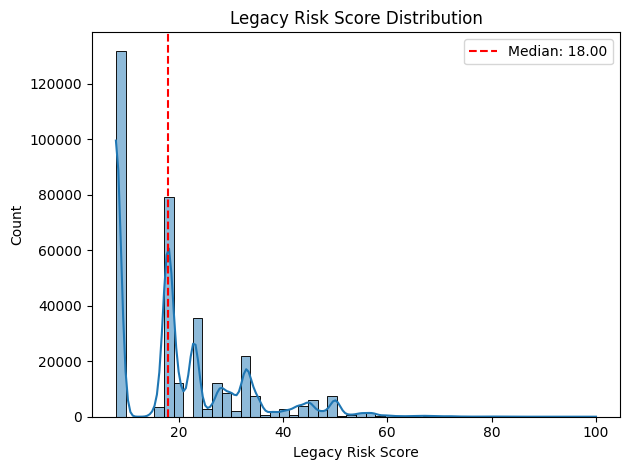

In [298]:
# `legacy_risk_score` distribution
sns.histplot(
    data=df,
    x="legacy_risk_score",
    bins=50,
    kde=True,
)
plt.axvline(df["legacy_risk_score"].median(), color="red", linestyle="--",
            label=f"Median: {df['legacy_risk_score'].median():,.2f}")
plt.title("Legacy Risk Score Distribution")
plt.xlabel("Legacy Risk Score")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [299]:
from sklearn.metrics import roc_auc_score
d = df.dropna(subset=["confirmed_fraud", "legacy_risk_score"])
print(roc_auc_score(d.confirmed_fraud.astype(int), d.legacy_risk_score))


0.8536440820246265


In [300]:
d.groupby("confirmed_fraud").legacy_risk_score.describe().rename(index={0: "Not Fraud", 1: "Fraud"})

,count,mean,std,min,25%,50%,75%,max
confirmed_fraud,,,,,,,,
Not Fraud,342991.0,19.251980,12.000481,8.0,8.0,18.0,23.0,99.0
Fraud,7009.0,40.868883,17.394966,8.0,30.0,38.0,50.0,100.0


The ROC-AUC of 0.85.4 proves `legacy_risk_score` is a strong baseline.

There is an 85.36% probability that a randomly chosen fraudulent transaction will be assigned a higher risk score by the legacy system than a randomly chosen clean transaction. This proves that whoever built the legacy rule-based scorecard captured high-signal indicators.

However, before deploying it, I will verify its source and timing: if this score was trained on our exact target label, it represents memorized data, and if it is computed after the transaction rather than in real time, it constitutes target leakage.

The approach will be to test with and without the scores and examine the feature relevance, but it only make sense to use if the legacy system will always be available.

`amount_ngn`

In [301]:
df["amount_ngn"].describe().to_frame().style.format("{:,.2f}")

,amount_ngn
count,"350,000.00"
mean,"52,649.21"
std,"146,008.11"
min,39.42
25%,"7,040.53"
50%,"18,164.99"
75%,"48,350.10"
max,"27,080,000.00"


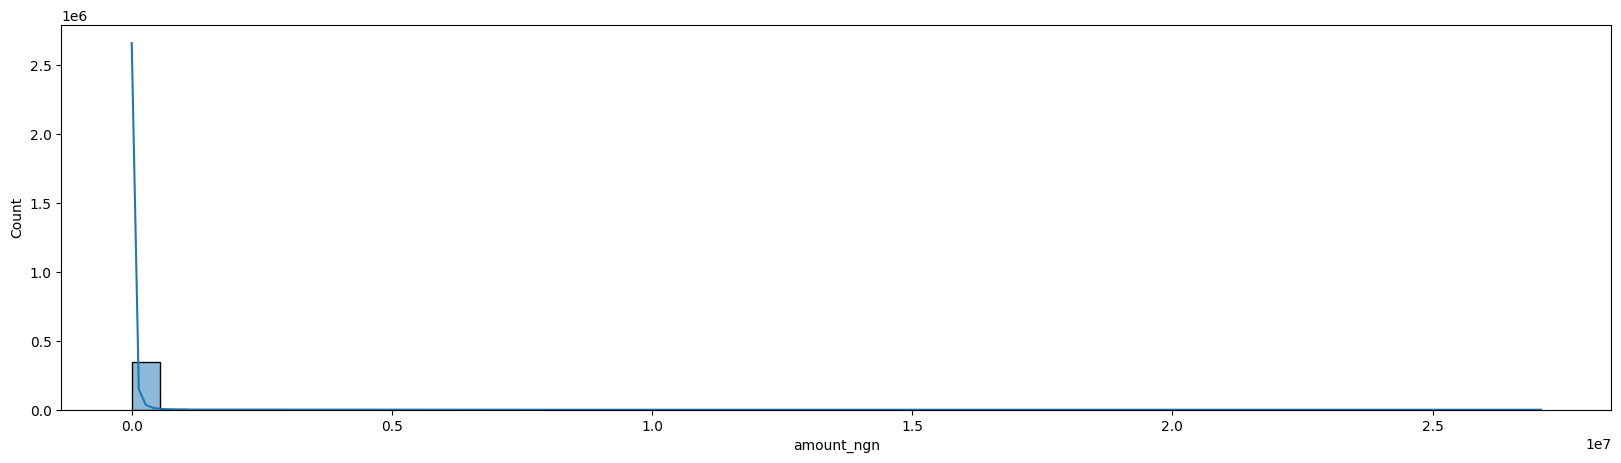

In [302]:
# amoung_ngn distribution

fig = plt.figure(figsize=(20,5))

sns.histplot(
    data=df,
    x="amount_ngn",
    bins=50,
    kde=True,
    )
plt.show()

In [303]:
cut_off_amount = df["amount_ngn"].quantile(0.99)

df_cut = df[df["amount_ngn"] <= cut_off_amount]
print(f"Cut-off Amount: {cut_off_amount:,.2f}\n")
print(f"Rows removed: {len(df) - len(df_cut)}\n")
print(f"Distrbution of Amount below 99% Percentile:")
df_cut[["amount_ngn"]].describe().style.format("{:,.2f}")

Cut-off Amount: 538,088.06

Rows removed: 3500

Distrbution of Amount below 99% Percentile:


,amount_ngn
count,"346,500.00"
mean,"43,168.24"
std,"68,670.02"
min,39.42
25%,"6,963.68"
50%,"17,845.12"
75%,"46,623.12"
max,"538,086.99"


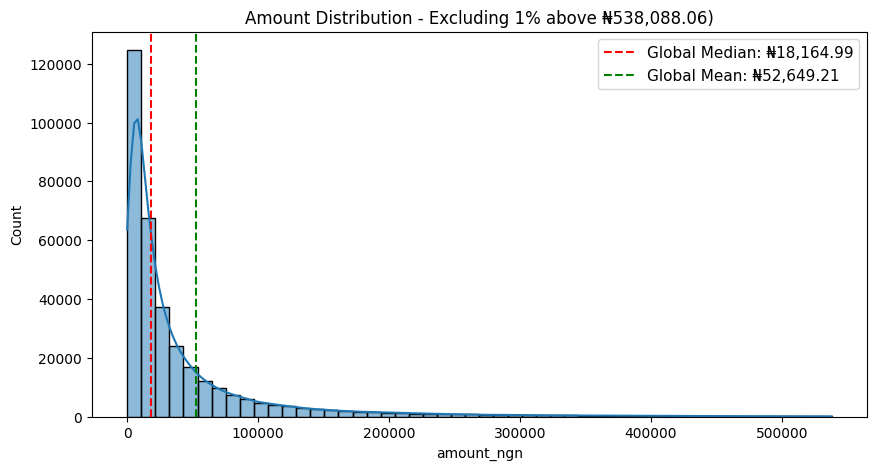

In [304]:
fig = plt.figure(figsize=(10,5))

sns.histplot(
    data=df_cut,
    x="amount_ngn",
    bins=50,
    kde=True,
    )
plt.axvline(df["amount_ngn"].median(), color="red", linestyle="--",
            label=f"Global Median: ₦{df['amount_ngn'].median():,.2f}")
plt.axvline(df["amount_ngn"].mean(), color="green", linestyle="--",
            label=f"Global Mean: ₦{df['amount_ngn'].mean():,.2f}")
plt.legend(loc="upper right", fontsize=11)
plt.title(f"Amount Distribution - Excluding 1% above ₦{cut_off_amount:,.2f})")
plt.show()

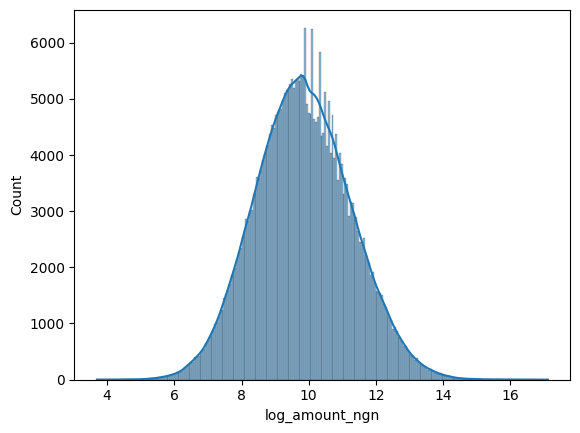

In [305]:
# Apply log transformation to correct skewness (using log1p to safely handle any potential 0 values)
df["log_amount_ngn"] = np.log1p(df["amount_ngn"])

sns.histplot(data=df, x="log_amount_ngn", kde=True)
plt.show()

In [306]:
# skew before and after
x = df["amount_ngn"].dropna()
print("raw skew:", x.skew(), "| log skew:", np.log1p(x).skew())

raw skew: 36.27055516149541 | log skew: 0.09852417665962858


`business_sector` and `merchant_country`

In [307]:
df.head(1)

,txn_ref,merchant_ref,txn_datetime,amount_ngn,business_sector,mcc_code,merchant_country,onboarded_last_30d,channel,dispute_outcome,legacy_risk_score,confirmed_fraud,txn_date,txn_dayofweek,txn_hour,txn_week,txn_month,is_weekend,is_night,is_month_end,is_month_start,log_amount_ngn
0,TXN-0000001,NGM-87116C,2025-01-01 00:04:17,65174.92,Logistics,5100,SN,No,Instant Transfer,No Dispute,43.0,0,2025-01-01,2,0,1,1,False,True,False,True,11.084845


In [308]:
print(f"Unique value count: {df['business_sector'].nunique()}\n")
df["business_sector"].value_counts(normalize=True)

Unique value count: 14



,proportion
business_sector,
Supermarkets,0.157766
Telecoms & Airtime,0.138577
Restaurants,0.118046
Fuel Stations,0.102054
Online Marketplaces,0.082037
Fashion,0.070834
Pharmacies,0.068051
Electronics,0.064194
Utilities & Bills,0.050963


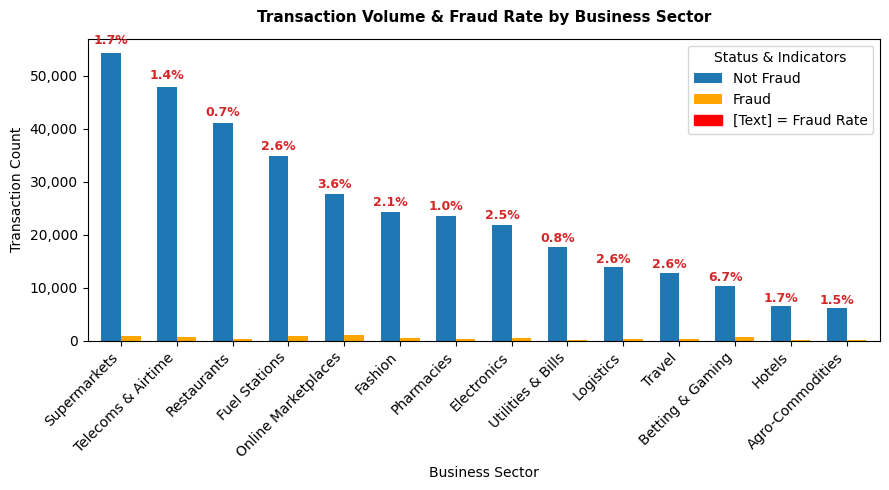

In [309]:
# Business sector distribution

sector_fraud_summary = df.groupby("business_sector").confirmed_fraud.value_counts().unstack(level=1)
sector_fraud_summary.columns = ["Not Fraud", "Fraud"]
sector_fraud_summary["total"] = sector_fraud_summary["Fraud"] + sector_fraud_summary["Not Fraud"]
sector_fraud_summary["fraud_rate"] = sector_fraud_summary["Fraud"] / sector_fraud_summary["total"]
sector_fraud_summary = sector_fraud_summary.sort_values(by="total", ascending=False)

ax = sector_fraud_summary[["Not Fraud", "Fraud"]].plot(
    kind="bar",
    stacked=False,
    width=0.7,
    color=["#1f77b4", "#FFA500"],
    figsize=(9, 5),
    rot=45
)

# print the exact fraud rate text above each cluster
for idx, bar in enumerate(ax.containers[1]):
    rate_text = f"{sector_fraud_summary['fraud_rate'].iloc[idx]:.1%}"

    # Calculate the midpoint position between the Not Fraud and Fraud bars
    bar_width = bar.get_width()
    center_x = bar.get_x() - (bar_width / 2)

    # Place the text above the highest bar in the cluster to prevent overlapping
    highest_y = max(sector_fraud_summary["Not Fraud"].iloc[idx], sector_fraud_summary["Fraud"].iloc[idx])

    ax.text(
        x=center_x,
        y=highest_y + (highest_y * 0.02),  #0.02 padding
        s=rate_text,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#d62728"   #orange
    )

plt.title("Transaction Volume & Fraud Rate by Business Sector", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Business Sector", fontsize=10)
plt.ylabel("Transaction Count", fontsize=10)

ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}")) #format Y-axis counts
plt.xticks(ha='right')

# Fetch legend handles
handles, labels = ax.get_legend_handles_labels()
fraud_text_handle = mpatches.Patch(color='red', label='[Text] = Fraud Rate')
handles.append(fraud_text_handle)
labels.append("[Text] = Fraud Rate")
ax.legend(handles=handles, labels=labels, title="Status & Indicators", loc="upper right")

plt.tight_layout()
plt.show()


**Sector volume vs fraud rate**

- Sectors are sorted by transaction volume, from high (left) to low (right).
- Supermarkets are the largest sector (over 55,000 transactions) with a fraud rate of 1.7%, slightly below the 2% average.
- Betting & Gaming is among the smallest (about 11,000 transactions) but has the highest fraud rate, 6.7%.
- Across the chart, the fraud rate goes up and down with no clear pattern as volume falls.
- **Decision:** Sector transaction volume does not predict risk, so grouping small sectors (like Betting & Gaming) into "Other" or using frequency encoding would lose information. Keep each sector as its own one-hot column.

In [310]:
print(f"Unique value count: {df['merchant_country'].nunique()}\n")
df["merchant_country"].value_counts(normalize=True)

Unique value count: 10



,proportion
merchant_country,
NG,0.519354
GH,0.100646
ZA,0.091911
KE,0.088509
EG,0.058554
SN,0.038806
CI,0.031974
TZ,0.028860
UG,0.021669


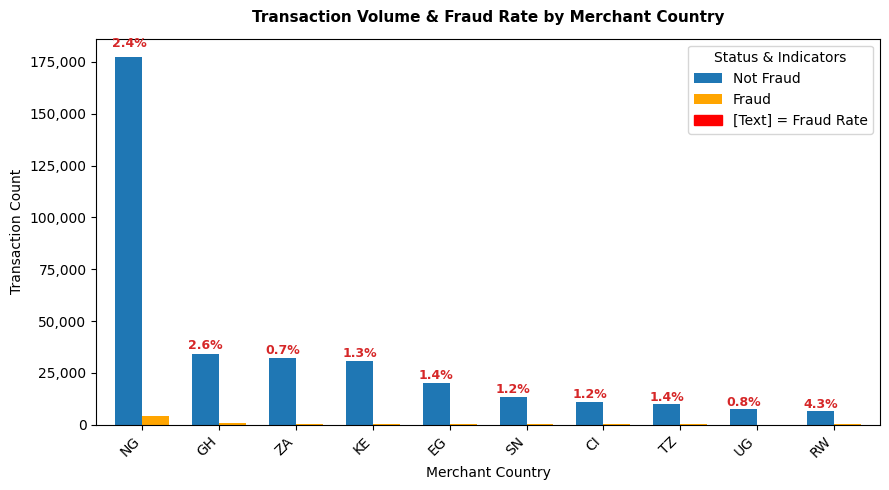

In [311]:
country_fraud_summary = df.groupby("merchant_country").confirmed_fraud.value_counts().unstack(level=1)
country_fraud_summary.columns = ["Not Fraud", "Fraud"]
country_fraud_summary["total"] = country_fraud_summary["Fraud"] + country_fraud_summary["Not Fraud"]
country_fraud_summary["fraud_rate"] = country_fraud_summary["Fraud"] / country_fraud_summary["total"]
country_fraud_summary = country_fraud_summary.sort_values(by="total", ascending=False)

ax = country_fraud_summary[["Not Fraud", "Fraud"]].plot(
    kind="bar",
    stacked=False,
    width=0.7,
    color=["#1f77b4", "#FFA500"],
    figsize=(9, 5),
    rot=45
)

# print the exact fraud rate text above each cluster
for idx, bar in enumerate(ax.containers[1]):
    rate_text = f"{country_fraud_summary['fraud_rate'].iloc[idx]:.1%}"

    # Calculate the midpoint position between the Not Fraud and Fraud bars
    bar_width = bar.get_width()
    center_x = bar.get_x() - (bar_width / 2)

    # Place the text above the highest bar in the cluster to prevent country_fraud_summary
    highest_y = max(country_fraud_summary["Not Fraud"].iloc[idx], sector_fraud_summary["Fraud"].iloc[idx])

    ax.text(
        x=center_x,
        y=highest_y + (highest_y * 0.02),  #0.02 padding
        s=rate_text,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#d62728"   #orange
    )

plt.title("Transaction Volume & Fraud Rate by Merchant Country", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Merchant Country", fontsize=10)
plt.ylabel("Transaction Count", fontsize=10)

ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}")) #format Y-axis counts
plt.xticks(ha='right')

# Fetch legend handles
handles, labels = ax.get_legend_handles_labels()
fraud_text_handle = mpatches.Patch(color='red', label='[Text] = Fraud Rate')
handles.append(fraud_text_handle)
labels.append("[Text] = Fraud Rate")
ax.legend(handles=handles, labels=labels, title="Status & Indicators", loc="upper right")

plt.tight_layout()
plt.show()


**Country volume vs fraud rate**

- Countries are sorted by transaction volume, from high (left) to low (right).
- NG (Nigeria) is the largest country by far (over 175,000 transactions) with a fraud rate of 2.4%, slightly above the dataset average.
- RW (Rwanda) is the smallest country (under 7,000 transactions) but has the highest fraud rate on the chart, 4.3%.
- Across the chart, the fraud rate goes up and down with no clear pattern as volume falls.
- **Decision:** Merchant Country transaction volume does not predict risk, so grouping small countries (like RW) into "Other" or using frequency encoding would lose signal. Keep each country as its own one-hot column.


In [312]:
df["mcc_code"].nunique()

328

In [313]:
mcc_top_10 = df.groupby("mcc_code")["confirmed_fraud"].mean().sort_values(ascending=False).head(10)
mcc_top_10

,confirmed_fraud
mcc_code,
5006,0.240914
5060,0.229167
5227,0.181287
4721,0.162633
4751,0.154110
4033,0.152174
4769,0.139303
5012,0.134812
4706,0.128101


In [314]:
print(f"Business Sectors and countries associated with high risk MCCs")
print(df[df["mcc_code"].isin(mcc_top_10.index)]["business_sector"].unique(),"\n")

print(f"Countries associated with high risk MCCs")
print(df[df["mcc_code"].isin(mcc_top_10.index)]["merchant_country"].unique())

Business Sectors and countries associated with high risk MCCs
['Betting & Gaming' 'Online Marketplaces' 'Supermarkets' 'Hotels'] 

Countries associated with high risk MCCs
['CI' 'ZA' 'GH' 'RW' 'NG' 'SN' 'KE' 'EG' 'TZ' 'UG']


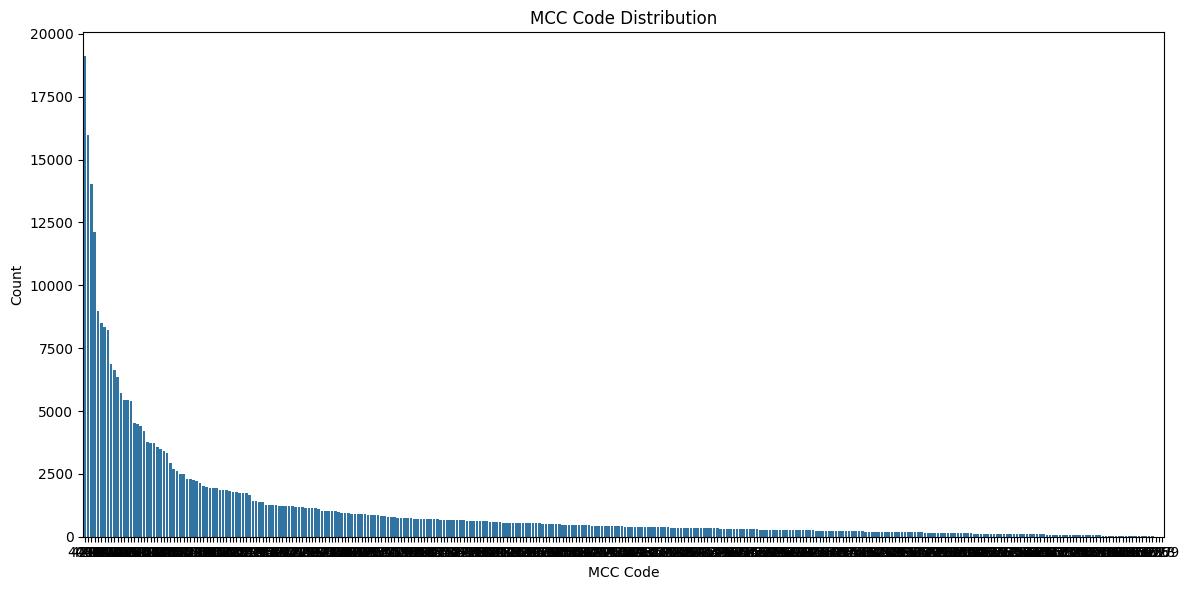

In [315]:
mcc_summary = df["mcc_code"].value_counts().sort_values(ascending=False).to_frame()

fig = plt.figure(figsize=(12,6))
sns.barplot(
    data=mcc_summary,
    x=mcc_summary.index,
    y="count",
    order=mcc_summary.index,)
plt.title("MCC Code Distribution")
plt.xlabel("MCC Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The mcc code distribution is extremely right skewed with long tail and high cardinality.

One-Hot Encoding injects 300+ sparse, empty columns. This balloons the feature space, drains memory, and slows down tree-splitting algorithms.

Frequency Grouping might destroys critical risk signals. High-risk, low-volume codes (e.g., Betting & Gaming) get blended with low-risk, low-volume codes (e.g., Agro-Commodities), flattening distinct profiles into an unhelpful average.

Therefore, Out-of-Fold (OOF) Target Encoding with Additive Smoothing is Best

It compresses the 300+ categories into exactly one numeric column while extracting clean, explicit risk signals from the most dominant MCC codes.
As for the long tail, additive smoothing pulls rare, noisy codes safely back toward the global average, while the OOF loop completely blocks data leakage during training.


`channel`

In [316]:
df["channel"].unique()

array(['Instant Transfer', 'POS Terminal', 'USSD/Wallet'], dtype=object)

In [317]:
channel_summary = df["channel"].value_counts()

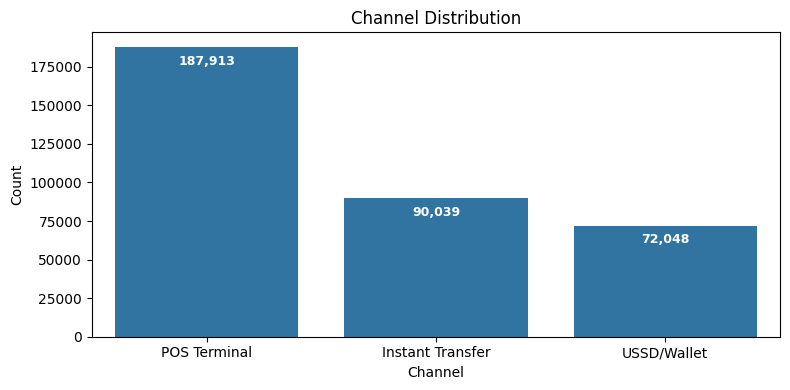

In [318]:
plt.figure(figsize=(8,4))
ax = sns.barplot(
    data=channel_summary.to_frame(),
    x=channel_summary.index,
    y="count",
    order=channel_summary.index,
)
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=-15, fontsize=9, fontweight="bold", color="white")
plt.title("Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [319]:
channel_fraud_rate= df.groupby("channel").confirmed_fraud.value_counts(normalize=True).unstack(level=1)
#channel_fraud_rate.columns = ["Not Fraud", "Fraud"]
channel_fraud_rate

confirmed_fraud,0,1
channel,,
Instant Transfer,0.966215,0.033785
POS Terminal,0.991257,0.008743
USSD/Wallet,0.967744,0.032256


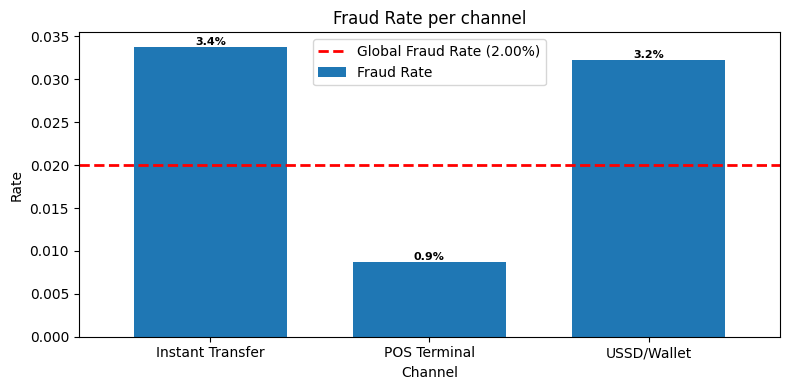

In [320]:
ax = channel_fraud_rate[1].plot(
    kind="bar",
    stacked=False,
    width=0.7,
    color=["#1f77b4"],
    figsize=(8,4),
    rot=0,
    label="Fraud Rate"
    )

ax.bar_label(
        ax.containers[0],
        fmt="{:.1%}",
        fontsize=8,
        fontweight="bold"
    )
plt.axhline(y=df["confirmed_fraud"].mean(), color='red', linestyle='--', linewidth=2, label=f'Global Fraud Rate ({df["confirmed_fraud"].mean():.2%})')

plt.title("Fraud Rate per channel")
plt.xlabel("Channel")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

POS is low-risk, Instant Transfer and USSD are high

In [321]:
df["onboarded_last_30d"].value_counts()

,count
onboarded_last_30d,
No,329077
Yes,20923


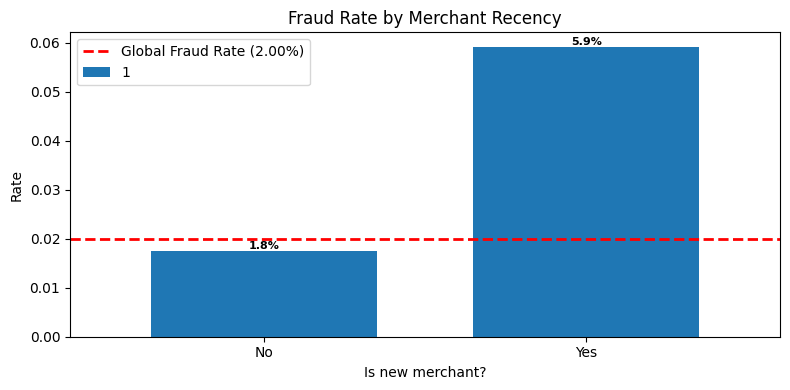

In [322]:
new_merchant = df.groupby("onboarded_last_30d").confirmed_fraud.value_counts(normalize=True).unstack(level=1)

ax = new_merchant[1].plot(
    kind="bar",
    stacked=False,
    width=0.7,
    color=["#1f77b4"],
    figsize=(8,4),
    rot=0
)
ax.bar_label(
        ax.containers[0],
        fmt="{:.1%}",
        fontsize=8,
        fontweight="bold"
    )
plt.axhline(y=df["confirmed_fraud"].mean(), color='red', linestyle='--', linewidth=2, label=f'Global Fraud Rate ({df["confirmed_fraud"].mean():.2%})')


plt.title("Fraud Rate by Merchant Recency")
plt.xlabel("Is new merchant?")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

new merchants carry about 3x the fraud rate

**Which Categorical Features Predict Fraud?**

**Method:** Information Value (IV) for each categorical feature against `confirmed_fraud`.


In [323]:
def compute_risk_metrics(df, feature, target="confirmed_fraud", alpha=0.05):
    """
    Computes Confidence Intervals (CI), Weight of Evidence (WoE),
    and overall Information Value (IV) for a categorical feature.
    """
    # overall global counts for reference
    total_safe = (df[target] == 0).sum()
    total_fraud = (df[target] == 1).sum()

    summary = df.groupby(feature)[target].agg(
        total_rows='count',
        fraud_rows='sum'
    ).reset_index()

    summary['safe_rows'] = summary['total_rows'] - summary['fraud_rows']
    summary['raw_fraud_rate'] = summary['fraud_rows'] / summary['total_rows']

    # z-critical value (e.g., 1.96 for a standard 95% confidence profile)
    z = stats.norm.ppf(1 - alpha / 2)

    # COMPUTE CONFIDENCE INTERVALS (Wald Method)
    margin_of_error = z * np.sqrt(
        (summary['raw_fraud_rate'] * (1 - summary['raw_fraud_rate'])) / summary['total_rows']
    )

    # Clip bounds between 0% and 100% to ensure logical consistency
    summary['ci_lower'] = np.clip(summary['raw_fraud_rate'] - margin_of_error, 0, 1)
    summary['ci_upper'] = np.clip(summary['raw_fraud_rate'] + margin_of_error, 0, 1)

    # COMPUTE WEIGHT OF EVIDENCE (WoE)
    # Apply +0.5 Laplace smoothing to protect against division-by-zero errors
    pct_safe_all = (summary['safe_rows'] + 0.5) / total_safe
    pct_fraud_all = (summary['fraud_rows'] + 0.5) / total_fraud

    summary['woe'] = np.log(pct_safe_all / pct_fraud_all)

    #COMPUTE INFORMATION VALUE (IV)
    summary['iv_contribution'] = (pct_safe_all - pct_fraud_all) * summary['woe']
    total_iv = summary['iv_contribution'].sum()

    # Clean up display formatting
    summary = summary.drop(columns=['iv_contribution'])

    # Interpret the summary grade based on credit-scoring standards
    if total_iv < 0.02:   grade = "Useless Noise (Drop it)"
    elif total_iv < 0.1:  grade = "Weak Predictor"
    elif total_iv < 0.3:  grade = "Medium Predictor"
    elif total_iv < 0.5:  grade = "Strong Predictor"
    else:                 grade = "Suspiciously High (Check for Data Leakage!)"

    return total_iv, grade, summary




In [324]:
categorical_variable = ["business_sector", "mcc_code", "merchant_country", "onboarded_last_30d",
                        "channel", "dispute_outcome" ]

In [325]:
for cat in categorical_variable:
    print(f"--- {cat} ---")
    column_iv, predictive_signal, metrics_df = compute_risk_metrics(df, feature=cat, target="confirmed_fraud")
    print(f"Information Value: {column_iv:.2f} | {predictive_signal}\n")


--- business_sector ---
Information Value: 0.31 | Strong Predictor

--- mcc_code ---
Information Value: 1.59 | Suspiciously High (Check for Data Leakage!)

--- merchant_country ---
Information Value: 0.16 | Medium Predictor

--- onboarded_last_30d ---
Information Value: 0.15 | Medium Predictor

--- channel ---
Information Value: 0.42 | Strong Predictor

--- dispute_outcome ---
Information Value: 3.17 | Suspiciously High (Check for Data Leakage!)



**Categorical Features vs Fraud (Information Value)**

- `channel` and `business_sector` are strong predictors. `merchant_country` and `onboarded_last_30d` are medium predictors.
- `dispute_outcome` is only known weeks after a transaction, so it cannot be used at prediction time. Its high IV is a consequence of fraud, not a predictor of it.
- `mcc_code` has 328 levels, so its IV is inflated. Fraud also comes in bursts from a few merchants (about 540 of 35,000), which makes some codes look riskier by luck. On unseen data (first 70% of time to learn, last 30% to test), its IV drops from 1.88 to 0.99, so only part of the signal is real.
- The "IV above 0.5 means leakage" rule suits features with about 10 groups, not 328.
- **Treatment:** one-hot encode the first four, use smoothed out-of-fold target encoding for `mcc_code`, and exclude `dispute_outcome`.
- **decision:** compare model PR-AUC with and without the encoded `mcc_code`.

----------------------------------------

**Merchant-Level and Behavioural Analysis**

In [326]:
# Transactions per merchant, active span, and amount mean, std, and max per merchant

In [327]:
df["merchant_first_seen"] = df.groupby("merchant_ref")["txn_datetime"].transform("min")
df["days_since_first_seen"] = (df["txn_datetime"] - df["merchant_first_seen"]).dt.days

In [328]:
df.tail(1)

,txn_ref,merchant_ref,txn_datetime,amount_ngn,business_sector,mcc_code,merchant_country,onboarded_last_30d,channel,dispute_outcome,legacy_risk_score,confirmed_fraud,txn_date,txn_dayofweek,txn_hour,txn_week,txn_month,is_weekend,is_night,is_month_end,is_month_start,log_amount_ngn,merchant_first_seen,days_since_first_seen
349999,TXN-0350000,NGM-472558,2025-12-31 23:58:18,17085.78,Fuel Stations,4112,NG,No,Instant Transfer,No Dispute,18.0,0,2025-12-31,2,23,1,12,False,False,True,False,9.74606,2025-01-07 14:27:21,358


In [329]:
g=df.groupby("merchant_ref")

df = df.sort_values(by=["merchant_ref", "txn_datetime"]).reset_index(drop=True)
g=df.groupby("merchant_ref")

merchant_summary = g.agg(
    n_txn=("txn_datetime", "count"),
    amount_mean=("amount_ngn", "mean"),
    amount_std=("amount_ngn", "std"),
    amount_max=("amount_ngn", "max"),
    first_txn_date=("txn_datetime", "min"),
    last_txn_date=("txn_datetime", "max"),
    n_channels=("channel", "nunique"),
    n_fraud=("confirmed_fraud", "sum"),
)

merchant_summary["active_span_days"] = (
    df["txn_datetime"].max() - merchant_summary["first_txn_date"]
).dt.total_seconds() / (60 * 60 * 24)

merchant_summary["txn_per_active_day"] = merchant_summary["n_txn"] / merchant_summary["active_span_days"].clip(lower=1)

merchant_summary["median_gap_hours"] = (g["txn_datetime"].diff().dt.total_seconds() / 3600
                                                    ).groupby(df.merchant_ref).median()

merchant_summary["merchant_type"] = np.where(merchant_summary["n_fraud"] == 0, "no fraud", "any fraud")

In [330]:
mt = merchant_summary.groupby("merchant_type")

median_metrics = mt[["n_txn", "active_span_days", "txn_per_active_day",
                             "median_gap_hours", "amount_mean"]].median()
median_metrics["n_merchants"] = mt.size()

result_table = median_metrics.T

result_table

merchant_type,any fraud,no fraud
n_txn,11.000000,6.000000
active_span_days,173.902691,321.152396
txn_per_active_day,0.075576,0.021654
median_gap_hours,11.472847,677.975556
amount_mean,54762.235625,24059.112500
n_merchants,530.000000,34470.000000


Fraudulent merchants are short-lived and busy. They do a lot in a few days, with big amounts and short gaps. Normal merchants trickle along over months.

**Feature Engineering for Transaction Detection**

In [331]:
df = df.sort_values(["merchant_ref", "txn_datetime"]).reset_index(drop=True)
g = df.groupby("merchant_ref")

df["secs_since_prev"] = g["txn_datetime"].diff().dt.total_seconds()
df["days_since_first_seen"] = (df["txn_datetime"] - g["txn_datetime"].transform("min")).dt.total_seconds() / 86400
df["n_prev_txn"] = g.cumcount()

df["log_amount_ngn"] = np.log1p(df["amount_ngn"])

# high-speed bitwise arrays for the searchsorted engine
mid = df["merchant_ref"].astype("category").cat.codes.to_numpy().astype("int64")
secs = (df["txn_datetime"] - pd.Timestamp("2025-01-01")).dt.total_seconds().to_numpy().astype("int64")
key = mid * 10**10 + secs
i = np.arange(len(key))

# Compute point-in-time lookback counts (natively drops the current row via side="left")
idx_1h  = np.searchsorted(key, key - 3600,  side="left")
idx_24h = np.searchsorted(key, key - 86400, side="left")
idx_7d  = np.searchsorted(key, key - 604800, side="left") # 7 days = 604,800 seconds

df["count_txn_1h"]  = i - idx_1h
df["count_txn_24h"] = i - idx_24h
df["count_txn_7d"]  = i - idx_7d

# point-in-time running sums using rolling cumulative sums
# To securely exclude the current row from the sum window, we map (cumsum - current_row)
amt_cumsum = g["log_amount_ngn"].cumsum().to_numpy()
amt_raw = df["log_amount_ngn"].to_numpy()

df["sum_amount_1h"]  = (amt_cumsum - amt_raw) - (np.take(amt_cumsum, idx_1h) - np.take(amt_raw, idx_1h))
df["sum_amount_24h"] = (amt_cumsum - amt_raw) - (np.take(amt_cumsum, idx_24h) - np.take(amt_raw, idx_24h))
df["sum_amount_7d"]  = (amt_cumsum - amt_raw) - (np.take(amt_cumsum, idx_7d) - np.take(amt_raw, idx_7d))

# Clean up structural edge cases where indices line up perfectly at the start of a window
df.loc[df["count_txn_1h"] == 0, "sum_amount_1h"] = 0
df.loc[df["count_txn_24h"] == 0, "sum_amount_24h"] = 0
df.loc[df["count_txn_7d"] == 0, "sum_amount_7d"] = 0

# burstiness metrics
df["burst_ratio"] = df["count_txn_1h"] / df["count_txn_24h"].where(df["count_txn_24h"] > 0)
df["burst_ratio"] = df["burst_ratio"].fillna(0)

# Z-Score
n_prev = df["n_prev_txn"]
sum_prev = g["log_amount_ngn"].cumsum() - df["log_amount_ngn"]
exp_mean_log = sum_prev / n_prev.where(n_prev > 0)

sum_sq_prev = (df["log_amount_ngn"] ** 2).groupby(df["merchant_ref"]).cumsum() - df["log_amount_ngn"] ** 2
var_prev = (sum_sq_prev - n_prev * exp_mean_log**2) / (n_prev - 1).where(n_prev > 1)
exp_std_log = np.sqrt(var_prev.clip(lower=0)).clip(lower=0.25) # Floor prevents division by zero

# Assign your merchant Z-Score, masked until a reliable history is established
df["amount_zscore_merchant"] = ((df["log_amount_ngn"] - exp_mean_log) / exp_std_log).where(n_prev >= 3).fillna(0).clip(-5, 5)

# industry peer baselines per MCC Code
mcc_group = df.groupby("mcc_code")["log_amount_ngn"]
mcc_mean_log = mcc_group.transform("mean")
mcc_std_log  = mcc_group.transform("std").clip(lower=0.25)

df["amount_zscore_mcc"] = (df["log_amount_ngn"] - mcc_mean_log) / mcc_std_log

df["log_vs_own_mean"] = df["log_amount_ngn"] - exp_mean_log


In [332]:
df = df.sort_values(["merchant_ref", "txn_datetime"]).reset_index(drop=True)
g = df.groupby("merchant_ref")

# round amounts (multiples of 5,000 are more common in fraud)
df["is_round_amount"] = ((df["amount_ngn"] >= 20_000) & (df["amount_ngn"] % 5000 == 0)).astype(int)

#
prev_max = g["amount_ngn"].cummax().groupby(df["merchant_ref"]).shift(1)
df["log_amt_vs_prev_max"] = np.log1p(df["amount_ngn"]) - np.log1p(prev_max)

# usualy transaction (on earlier rows)
def prev_share(flag):
    s = flag.groupby(df["merchant_ref"]).cumsum() - flag
    return s / df["n_prev_txn"].where(df["n_prev_txn"] > 0)
df["prev_night_share"]   = prev_share((df["txn_hour"] <= 5).astype(int))
df["prev_instant_share"] = prev_share(df["channel"].isin(["Instant Transfer", "USSD/Wallet"]).astype(int))

# channel change from the previous transaction
prev_ch = g["channel"].shift(1)
df["channel_changed"] = (df["channel"] != prev_ch).astype(float).where(prev_ch.notna())

# no of different channels used before
df["n_channels_prev"] = sum(
    (((df["channel"] == c).groupby(df["merchant_ref"]).cumsum() - (df["channel"] == c)) > 0).astype(int)
    for c in df["channel"].dropna().unique()
)

# average amount in the last 24 hours
df["avg_amount_24h"] = df["sum_amount_24h"] / df["count_txn_24h"].where(df["count_txn_24h"] > 0)

# the legacy score defaults to exactly 50 when it times out
df["legacy_score_is_50"] = (df["legacy_risk_score"] == 50).astype(int)

# cyclical time. raw hour for trees, sin/cos for logistic
df["hour_sin"] = np.sin(2 * np.pi * df["txn_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["txn_hour"] / 24)

In [333]:
df['is_night'] = df['is_night'].astype(int)
df["onboarded_last_30d"] = df["onboarded_last_30d"].map({"No": 0, "Yes": 1})

In [334]:
df.columns

Index(['txn_ref', 'merchant_ref', 'txn_datetime', 'amount_ngn',
       'business_sector', 'mcc_code', 'merchant_country', 'onboarded_last_30d',
       'channel', 'dispute_outcome', 'legacy_risk_score', 'confirmed_fraud',
       'txn_date', 'txn_dayofweek', 'txn_hour', 'txn_week', 'txn_month',
       'is_weekend', 'is_night', 'is_month_end', 'is_month_start',
       'log_amount_ngn', 'merchant_first_seen', 'days_since_first_seen',
       'secs_since_prev', 'n_prev_txn', 'count_txn_1h', 'count_txn_24h',
       'count_txn_7d', 'sum_amount_1h', 'sum_amount_24h', 'sum_amount_7d',
       'burst_ratio', 'amount_zscore_merchant', 'amount_zscore_mcc',
       'log_vs_own_mean', 'is_round_amount', 'log_amt_vs_prev_max',
       'prev_night_share', 'prev_instant_share', 'channel_changed',
       'n_channels_prev', 'avg_amount_24h', 'legacy_score_is_50', 'hour_sin',
       'hour_cos'],
      dtype='object')

In [335]:
df.tail(1)

,txn_ref,merchant_ref,txn_datetime,amount_ngn,business_sector,mcc_code,merchant_country,onboarded_last_30d,channel,dispute_outcome,legacy_risk_score,confirmed_fraud,txn_date,txn_dayofweek,txn_hour,txn_week,txn_month,is_weekend,is_night,is_month_end,is_month_start,log_amount_ngn,merchant_first_seen,days_since_first_seen,secs_since_prev,n_prev_txn,count_txn_1h,count_txn_24h,count_txn_7d,sum_amount_1h,sum_amount_24h,sum_amount_7d,burst_ratio,amount_zscore_merchant,amount_zscore_mcc,log_vs_own_mean,is_round_amount,log_amt_vs_prev_max,prev_night_share,prev_instant_share,channel_changed,n_channels_prev,avg_amount_24h,legacy_score_is_50,hour_sin,hour_cos
349999,TXN-0106093,NGM-FFFFC4,2025-04-27 17:22:10,26297.54,Fuel Stations,4100,ZA,1,Instant Transfer,No Dispute,30.0,0,2025-04-27,6,17,17,4,True,0,False,False,10.177269,2025-04-27 17:22:10,0.0,NaN,0,0,0,0,0.0,0.0,0.0,0.0,0.0,-0.022556,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,-0.965926,-0.258819


In [336]:
categorical_features = ['business_sector', 'mcc_code', 'merchant_country', 'channel']
numerical_features = ['days_since_first_seen', 'secs_since_prev',  'n_prev_txn', 'log_amount_ngn',
                    'count_txn_1h', 'count_txn_24h', 'count_txn_7d' , 'burst_ratio', 'amount_zscore_merchant',
                    'amount_zscore_mcc', 'log_vs_own_mean', 'log_amt_vs_prev_max',
                    'prev_night_share', 'prev_instant_share', 'channel_changed',
                    'n_channels_prev', 'avg_amount_24h', 'hour_sin', 'hour_cos',
                    'legacy_risk_score']

target = ['confirmed_fraud']

bool_features = ['onboarded_last_30d', 'is_night', 'is_round_amount', 'legacy_score_is_50']


drop_features = ['txn_dayofweek', 'txn_hour', 'txn_week', 'txn_month',
            'amount_ngn', 'is_weekend', 'is_month_end', 'is_month_start',
            'sum_amount_1h','sum_amount_24h', 'sum_amount_7d']

id_features = ['merchant_ref', 'txn_ref', 'dispute_outcome']

datetime_features = ['txn_datetime', 'txn_date', 'merchant_first_seen']

**More Explorations**

Spearman Correlation for numerics

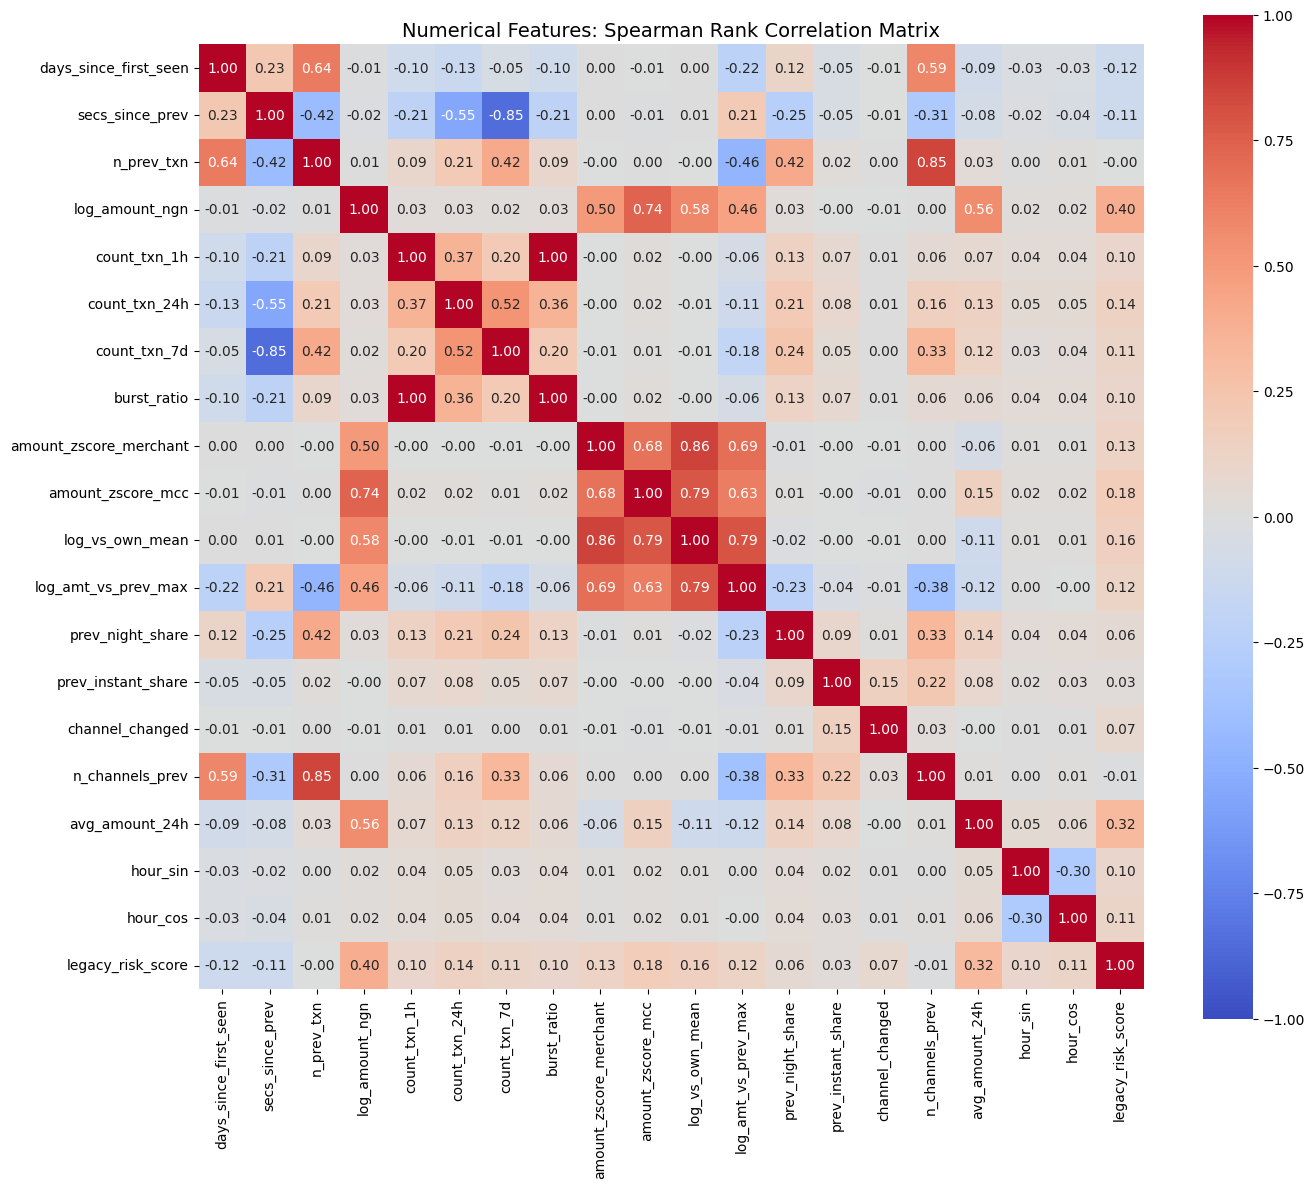

In [337]:

spearman_matrix = df[numerical_features].corr(method="spearman")

# Numerical Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Numerical Features: Spearman Rank Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


Cramér's V for corelation of categorical variable

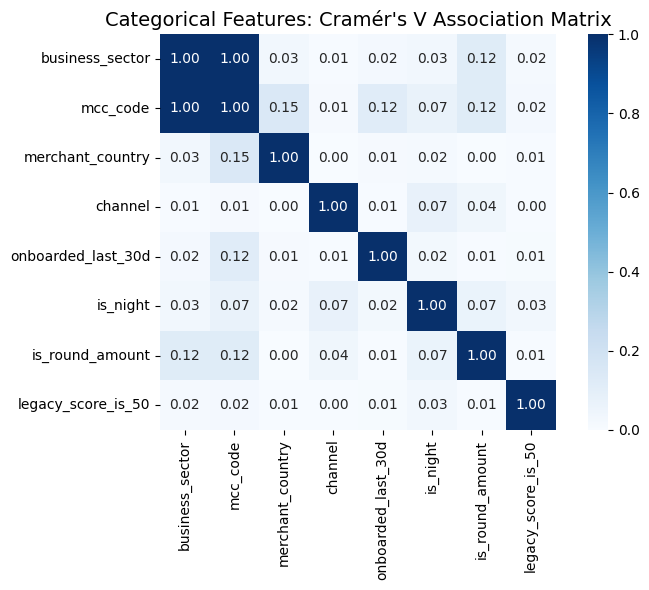

In [338]:
#Cramér's V mathematical function
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Applying bias correction for small cell counts or high-cardinality flags
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min((kcorr - 1), (rcorr - 1))
    if denominator == 0:
        return 0.0
    return np.sqrt(phi2corr / denominator)


categorical_cols = categorical_features + bool_features

cramers_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float) #empty frame

# Store the association values in the dataframe
for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Categorical Association Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
)
plt.title("Categorical Features: Cramér's V Association Matrix", fontsize=14)
plt.tight_layout()
plt.show()


In [339]:
# check for skewness

print("Skewness of numerical features:\n")
print(f"{'Column':<25} | {'Skewness':>10} | {'Recommendation'}")
print(f"-"*75)

for col in numerical_features:
    skew_value = df[col].skew()

    if -0.5 <= skew_value <= 0.5:
        d = "Normal"
    elif 0.5 < skew_value <= 1.0:
        d = "Moderately Right-skewed"
    elif skew_value > 1.0:
        d = "Extremely Right-skewed"
    elif -1.0 <= skew_value < -0.5:
        d = "Moderately Left-skewed"
    elif skew_value < -1.0:
        d = "Extremely Left-skewed"
    else:
        d = "Unknown / Edge case"  # Safety fallback

    # Fixed the formatting error here
    print(f"{col:<25} | {skew_value:>10.2f} | {d:>5}")


Skewness of numerical features:

Column                    |   Skewness | Recommendation
---------------------------------------------------------------------------
days_since_first_seen     |       0.34 | Normal
secs_since_prev           |       3.08 | Extremely Right-skewed
n_prev_txn                |       4.15 | Extremely Right-skewed
log_amount_ngn            |       0.10 | Normal
count_txn_1h              |      15.35 | Extremely Right-skewed
count_txn_24h             |      13.86 | Extremely Right-skewed
count_txn_7d              |      15.19 | Extremely Right-skewed
burst_ratio               |      12.38 | Extremely Right-skewed
amount_zscore_merchant    |       0.03 | Normal
amount_zscore_mcc         |       0.04 | Normal
log_vs_own_mean           |       0.02 | Normal
log_amt_vs_prev_max       |       0.15 | Normal
prev_night_share          |       4.10 | Extremely Right-skewed
prev_instant_share        |       0.17 | Normal
channel_changed           |      -0.42 | Normal
n_c

In [340]:
# Apply log transformation to the columns with extreme skewness

for c in ["count_txn_1h", "count_txn_24h", "count_txn_7d", "secs_since_prev", "days_since_first_seen", "n_prev_txn",
              "burst_ratio", "prev_night_share", "legacy_risk_score"]:

    df[f"log_{c}"] = np.log1p(df[c])


**Time aware split**

In [341]:
print(f"Dataset time period: {df['txn_datetime'].min()} - {df['txn_datetime'].max()}")

Dataset time period: 2025-01-01 00:04:17 - 2025-12-31 23:58:18


In [342]:
df_final = df.sort_values(by="txn_datetime").reset_index(drop=True)

val_cutoff = pd.to_datetime("2025-11-01 00:00:00") # Everything before November 2025 goes to Training


test_cutoff = pd.to_datetime("2025-12-01 00:00:00") # December 2025 is reserved purely for the final Test data

train_df = df_final[df_final["txn_datetime"] < val_cutoff].copy()
val_df   = df_final[(df_final["txn_datetime"] >= val_cutoff) & (df_final["txn_datetime"] < test_cutoff)].copy()
test_df  = df_final[df_final["txn_datetime"] >= test_cutoff].copy()

print(f"--- Time Aware Split Summary ---")
print(f"1. Train Set:      {train_df['txn_datetime'].min()} to {train_df['txn_datetime'].max()} ({len(train_df):,} rows)")
print(f"2. Validation Set: {val_df['txn_datetime'].min()} to {val_df['txn_datetime'].max()} ({len(val_df):,} rows)")
print(f"3. Test Set:       {test_df['txn_datetime'].min()} to {test_df['txn_datetime'].max()} ({len(test_df):,} rows)\n")

print(f"Fraud Rate (Train): {train_df['confirmed_fraud'].mean():.4%}")
print(f"Fraud Rate (Val):   {val_df['confirmed_fraud'].mean():.4%}")
print(f"Fraud Rate (Test):  {test_df['confirmed_fraud'].mean():.4%}")


--- Time Aware Split Summary ---
1. Train Set:      2025-01-01 00:04:17 to 2025-10-31 23:47:06 (295,227 rows)
2. Validation Set: 2025-11-01 00:36:06 to 2025-11-30 23:59:05 (27,598 rows)
3. Test Set:       2025-12-01 00:31:20 to 2025-12-31 23:58:18 (27,175 rows)

Fraud Rate (Train): 1.9839%
Fraud Rate (Val):   2.2103%
Fraud Rate (Test):  1.9945%


Model Training

In [343]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
from sklearn.model_selection import KFold, GroupKFold

Baseline: Logistic with legacy_risk_score

In [344]:

def evaluate(y, p, top_fracs=(0.02, 0.05, 0.10)):
    y, p = np.asarray(y), np.asarray(p)
    out = {"pr_auc": average_precision_score(y, p), "roc_auc": roc_auc_score(y, p)}
    order = np.argsort(-p)
    for f in top_fracs:
        k = int(len(y) * f); hit = y[order[:k]].sum()
        out[f"recall@{int(f*100)}%"] = hit / y.sum()
        out[f"precision@{int(f*100)}%"] = hit / k
    return out

In [345]:
X_train,  y_train = train_df['log_legacy_risk_score'], train_df['confirmed_fraud']
X_val, y_val = val_df['log_legacy_risk_score'], val_df['confirmed_fraud']
X_test = test_df['log_legacy_risk_score']

log_base_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

log_base_model.fit(X_train.values.reshape(-1, 1), y_train)

y_pred_log_base_train = log_base_model.predict_proba(X_train.values.reshape(-1, 1))[:, 1]
y_pred_log_base_val = log_base_model.predict_proba(X_val.values.reshape(-1, 1))[:, 1]

print(f"PR-AUC (Average Precision) on Train: {average_precision_score(y_train, y_pred_log_base_train):.4f}")
print(f"PR-AUC (Average Precision) on Validation: {average_precision_score(y_val, y_pred_log_base_val):.4f}")

PR-AUC (Average Precision) on Train: 0.1789
PR-AUC (Average Precision) on Validation: 0.3216


Linear Model: all features without legacy_risk_score and `mcc_code`

In [346]:
num = numerical_features.copy()
cat = categorical_features.copy()

num = [x for x in num if x not in ["legacy_risk_score", "legacy_score_is_50"]]
cat.remove("mcc_code")

X_train, y_train = train_df[num + cat], train_df['confirmed_fraud']
X_val, y_val = val_df[num + cat], val_df['confirmed_fraud']
X_test = test_df[num + cat]

col_transformer = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median", add_indicator=True)),
            ("num", StandardScaler())
        ]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ],
)

log_model = Pipeline(
    steps=[
        ("preprocessing", col_transformer),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

log_model.fit(X_train, y_train)

evaluate(y_val, log_model.predict_proba(X_val)[:, 1])

{'pr_auc': np.float64(0.9040725754408271),
 'roc_auc': np.float64(0.9977589311096371),
 'recall@2%': np.float64(0.7688524590163934),
 'precision@2%': np.float64(0.8511796733212341),
 'recall@5%': np.float64(1.0),
 'precision@5%': np.float64(0.4423495286439449),
 'recall@10%': np.float64(1.0),
 'precision@10%': np.float64(0.22109459949256977)}

LightGBM, with and without the legacy score

In [347]:
import lightgbm as lgb

cat_tree = ["business_sector", "merchant_country", "channel", "onboarded_last_30d"]
levels = {c: sorted(df[c].dropna().unique()) for c in cat_tree}    # same categories in every block

def make_X(d, cols):
    X = d[cols].copy()
    for c in cat_tree:
        if c in X: X[c] = pd.Categorical(X[c], categories=levels[c])
    return X

tree_num = ["log_amount_ngn", "txn_hour", "is_night", "count_txn_1h", "count_txn_24h", "count_txn_7d", "secs_since_prev",
            "days_since_first_seen", "n_prev_txn", "burst_ratio", "amount_zscore_merchant", "amount_zscore_mcc",
            "log_vs_own_mean", "is_round_amount", "log_amt_vs_prev_max", "prev_night_share", "prev_instant_share",
            "channel_changed", "n_channels_prev", "avg_amount_24h"]

cols_A = tree_num + cat_tree                                       # without the legacy score
cols_B = cols_A + ["legacy_risk_score", "legacy_score_is_50"]      # with it

def fit_lgb(cols, **kw):
    m = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.03, num_leaves=15, max_depth=5, min_child_samples=50,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                           random_state=42, verbose=-1, **kw)
    m.fit(make_X(train_df, cols), train_df["confirmed_fraud"],
          eval_set=[(make_X(val_df, cols), val_df["confirmed_fraud"])], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    return m

scale_pos_weight = train_df["confirmed_fraud"].value_counts()[0] / train_df["confirmed_fraud"].value_counts()[1]
result = {}
for name, cols in [("with no legacy", cols_A), ("with legacy", cols_B)]:
    m = fit_lgb(cols, scale_pos_weight=scale_pos_weight)
    result.update({name: evaluate(val_df["confirmed_fraud"], m.predict_proba(make_X(val_df, cols))[:, 1])})



Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[59]	valid_0's average_precision: 0.904366	valid_0's binary_logloss: 0.0254238
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[62]	valid_0's average_precision: 0.902491	valid_0's binary_logloss: 0.0253846


In [348]:
print("Result without scale pos weight")

for name, metrics in result.items():
    print(f"LighGBM {name}")
    for res in metrics:
        print(f"{res}: {metrics[res]}")
    print(f"\n")


Result without scale pos weight
LighGBM with no legacy
pr_auc: 0.9043664063004337
roc_auc: 0.9977681641142266
recall@2%: 0.7540983606557377
precision@2%: 0.8348457350272233
recall@5%: 1.0
precision@5%: 0.4423495286439449
recall@10%: 1.0
precision@10%: 0.22109459949256977


LighGBM with legacy
pr_auc: 0.9024907234574858
roc_auc: 0.9977769719146579
recall@2%: 0.759016393442623
precision@2%: 0.8402903811252269
recall@5%: 1.0
precision@5%: 0.4423495286439449
recall@10%: 1.0
precision@10%: 0.22109459949256977




In [349]:
print("Result with scale pos weight")
for name, metrics in result.items():
    print(f"LighGBM {name}")
    for res in metrics:
        print(f"{res}: {metrics[res]}")
    print(f"\n")


Result with scale pos weight
LighGBM with no legacy
pr_auc: 0.9043664063004337
roc_auc: 0.9977681641142266
recall@2%: 0.7540983606557377
precision@2%: 0.8348457350272233
recall@5%: 1.0
precision@5%: 0.4423495286439449
recall@10%: 1.0
precision@10%: 0.22109459949256977


LighGBM with legacy
pr_auc: 0.9024907234574858
roc_auc: 0.9977769719146579
recall@2%: 0.759016393442623
precision@2%: 0.8402903811252269
recall@5%: 1.0
precision@5%: 0.4423495286439449
recall@10%: 1.0
precision@10%: 0.22109459949256977




Encode `mcc_code`

In [350]:
def te_fit(cat, y, m=20):
    prior = y.mean()
    g = pd.DataFrame({"c": cat.values, "y": y.values}).groupby("c")["y"].agg(["sum", "count"])
    return (g["sum"] + m * prior) / (g["count"] + m), prior

def te_apply(cat, mapping, prior):
    return cat.map(mapping).fillna(prior).astype(float).to_numpy()

def te_oof(cat, y, groups, m=20, k=5, seed=0):
    out = np.empty(len(cat))
    gkf = GroupKFold(n_splits=k)
    for a, b in gkf.split(cat, y, groups=groups):
        mp, pr = te_fit(cat.iloc[a], y.iloc[a], m)
        out[b] = te_apply(cat.iloc[b], mp, pr)
    return out

In [351]:
M = 20
y_tr = train_df["confirmed_fraud"]
train_df["mcc_te"] = te_oof(train_df["mcc_code"], y_tr, groups=train_df["merchant_ref"], m=M)
mp, pr = te_fit(train_df["mcc_code"], y_tr, m=M)
val_df["mcc_te"] = te_apply(val_df["mcc_code"], mp, pr)
test_df["mcc_te"]  = te_apply(test_df["mcc_code"],  mp, pr)

variants = {"no mcc": cols_A,
            "mcc target enc (flat)": cols_A + ["mcc_te"]}

In [352]:
groups = {"velocity": ["count_txn_1h", "count_txn_24h", "count_txn_7d", "burst_ratio", "avg_amount_24h"],
          "gap_and_age": ["secs_since_prev", "days_since_first_seen", "n_prev_txn"],
          "zscores": ["amount_zscore_merchant", "amount_zscore_mcc", "log_vs_own_mean", "log_amt_vs_prev_max"],
          "history_shares": ["prev_night_share", "prev_instant_share", "channel_changed", "n_channels_prev"],
          "time": ["txn_hour", "is_night"]}
for gname, gcols in groups.items():
    cols = [c for c in cols_A if c not in gcols]
    m = fit_lgb(cols)
    print("without", gname, evaluate(val_df["confirmed_fraud"], m.predict_proba(make_X(val_df, cols))[:, 1])["pr_auc"])

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[215]	valid_0's average_precision: 0.92633	valid_0's binary_logloss: 0.0176458
without velocity 0.9263300850551843
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[186]	valid_0's average_precision: 0.918339	valid_0's binary_logloss: 0.0193329
without gap_and_age 0.918339465533942
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[217]	valid_0's average_precision: 0.92344	valid_0's binary_logloss: 0.0176901
without zscores 0.9234404931056106
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[96]	valid_0's average_precision: 0.920554	valid_0's binary_logloss: 0.0212445
without history_shares 0.9205536677881062
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[564]	valid_0's average_precision: 0.852851	val

Step 8: Merchant roll-up and detection speed

In [353]:
m_best = fit_lgb(cols_A)
best_iter = m_best.best_iteration_

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[215]	valid_0's average_precision: 0.924012	valid_0's binary_logloss: 0.017655


In [354]:
test_df["p"] = m_best.predict_proba(make_X(test_df, cols_A))[:, 1]

m_score = test_df.groupby("merchant_ref")["p"].max()
m_label = test_df.groupby("merchant_ref")["confirmed_fraud"].max()
print("merchant roll-up:\n")
evaluate(m_label.loc[m_score.index], m_score)

merchant roll-up:



{'pr_auc': np.float64(0.9962959756848264),
 'roc_auc': np.float64(0.9999842023844678),
 'recall@2%': np.float64(1.0),
 'precision@2%': np.float64(0.1972318339100346),
 'recall@5%': np.float64(1.0),
 'precision@5%': np.float64(0.0787292817679558),
 'recall@10%': np.float64(1.0),
 'precision@10%': np.float64(0.039337474120082816)}

In [355]:
p_valid = m_best.predict_proba(make_X(val_df, cols_A))[:, 1]   # score per payment
yv = val_df["confirmed_fraud"].to_numpy()                      # 1 = fraud
av = val_df["amount_ngn"].to_numpy()                           # naira amount, kept aside (not a feature)

In [356]:
def cost_curve(y, p, amount, thresholds, review_cost=2_000):
    y, p, amount = map(np.asarray, (y, p, amount))
    all_fraud_naira = amount[y == 1].sum()
    rows = []
    for th in thresholds:
        flag = p >= th
        caught = flag & (y == 1)
        rows.append({
            "threshold": th,
            "flagged_share": flag.mean(),
            "recall": caught.sum() / y.sum(),
            "precision": caught.sum() / max(flag.sum(), 1),
            "fraud_naira_missed": all_fraud_naira - amount[caught].sum(),
            "review_naira": flag.sum() * review_cost,
        })
    out = pd.DataFrame(rows)
    out["total_cost"] = out["fraud_naira_missed"] + out["review_naira"]
    return out

curve = cost_curve(yv, p_valid, av, thresholds=np.arange(0.01, 1.00, 0.01), review_cost=2_000)
curve.head()

,threshold,flagged_share,recall,precision,fraud_naira_missed,review_naira,total_cost
0,0.01,0.031995,0.981967,0.678369,609089.11,1766000,2375089.11
1,0.02,0.031162,0.972131,0.689535,921573.97,1720000,2641573.97
2,0.03,0.030727,0.965574,0.694575,1083677.94,1696000,2779677.94
3,0.04,0.030401,0.963934,0.700834,1096201.46,1678000,2774201.46
4,0.05,0.030075,0.955738,0.702410,1697341.85,1660000,3357341.85


In [357]:
best_row = curve.loc[curve["total_cost"].idxmin()]
best_thr = best_row["threshold"]
print(best_row.round(3))

no_model_cost = av[yv == 1].sum()                 # you flag nothing
review_all_cost = len(yv) * 2_000                 # you review everything
print("cost with model :", round(best_row["total_cost"]))
print("cost, no model  :", round(no_model_cost))
print("cost, review all:", round(review_all_cost))
print("naira saved vs no model:", round(no_model_cost - best_row["total_cost"]))

threshold                   0.010
flagged_share               0.032
recall                      0.982
precision                   0.678
fraud_naira_missed     609089.110
review_naira          1766000.000
total_cost            2375089.110
Name: 0, dtype: float64
cost with model : 2375089
cost, no model  : 125720620
cost, review all: 55196000
naira saved vs no model: 123345531


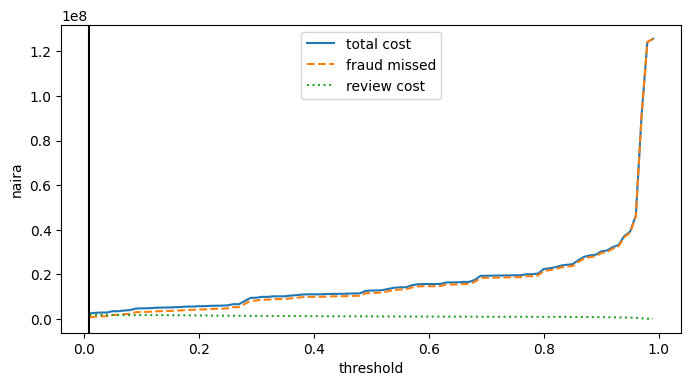

In [358]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(curve["threshold"], curve["total_cost"], label="total cost")
plt.plot(curve["threshold"], curve["fraud_naira_missed"], ls="--", label="fraud missed")
plt.plot(curve["threshold"], curve["review_naira"], ls=":", label="review cost")
plt.axvline(best_thr, c="k"); plt.xlabel("threshold"); plt.ylabel("naira"); plt.legend(); plt.show()

In [359]:
near = curve[curve["total_cost"] <= best_row["total_cost"] * 1.02]    # within 2% of the minimum
best_thr_stable = near["threshold"].median()

In [360]:
for rc in (500, 2_000, 5_000):
    c = cost_curve(yv, p_valid, av, np.arange(0.01, 1.00, 0.01), review_cost=rc)
    r = c.loc[c["total_cost"].idxmin()]
    print(f"review cost {rc:>5}: threshold {r['threshold']:.2f}, flags {r['flagged_share']:.2%}, recall {r['recall']:.2%}")

review cost   500: threshold 0.01, flags 3.20%, recall 98.20%
review cost  2000: threshold 0.01, flags 3.20%, recall 98.20%
review cost  5000: threshold 0.01, flags 3.20%, recall 98.20%


In [361]:
best_thr = 0.010

# how quickly is a fraud merchant first flagged?
test_df["flag"] = test_df["p"] >= best_thr
first_fraud = test_df[test_df.confirmed_fraud == 1].groupby("merchant_ref")["txn_datetime"].min()
first_flag  = test_df[test_df.flag].groupby("merchant_ref")["txn_datetime"].min()
delay_h = ((first_flag.reindex(first_fraud.index) - first_fraud).dt.total_seconds() / 3600)
print("never flagged:", delay_h.isna().mean(), "| median delay (hours):", delay_h.median())

never flagged: 0.0 | median delay (hours): 0.0


In [362]:
yv = val_df["confirmed_fraud"].to_numpy()
fracs = (0.005, 0.01, 0.02, 0.03, 0.05)

scores = {
    "Legacy score alone":       val_df["legacy_risk_score"].to_numpy(),
    "Logistic (no legacy)":     log_model.predict_proba(val_df[num + cat])[:, 1],
    "LightGBM (no legacy)":     m_best.predict_proba(make_X(val_df, cols_A))[:, 1],
    #"LightGBM (+ legacy)":      m_legacy.predict_proba(make_X(val_df, cols_B))[:, 1],
}
res = pd.DataFrame({k: evaluate(yv, v, top_fracs=fracs) for k, v in scores.items()}).T
res["lift@2%"] = res["precision@2%"] / yv.mean()          # times better than random review
res.round(3)

,pr_auc,roc_auc,recall@0%,precision@0%,recall@1%,precision@1%,recall@2%,precision@2%,recall@3%,precision@3%,recall@5%,precision@5%,lift@2%
Legacy score alone,0.322,0.897,0.152,0.679,0.248,0.549,0.323,0.358,0.352,0.260,0.479,0.212,16.176
Logistic (no legacy),0.904,0.998,0.220,0.978,0.430,0.953,0.769,0.851,0.959,0.707,1.000,0.442,38.510
LightGBM (no legacy),0.924,0.998,0.223,0.993,0.436,0.967,0.793,0.878,0.952,0.703,1.000,0.442,39.741


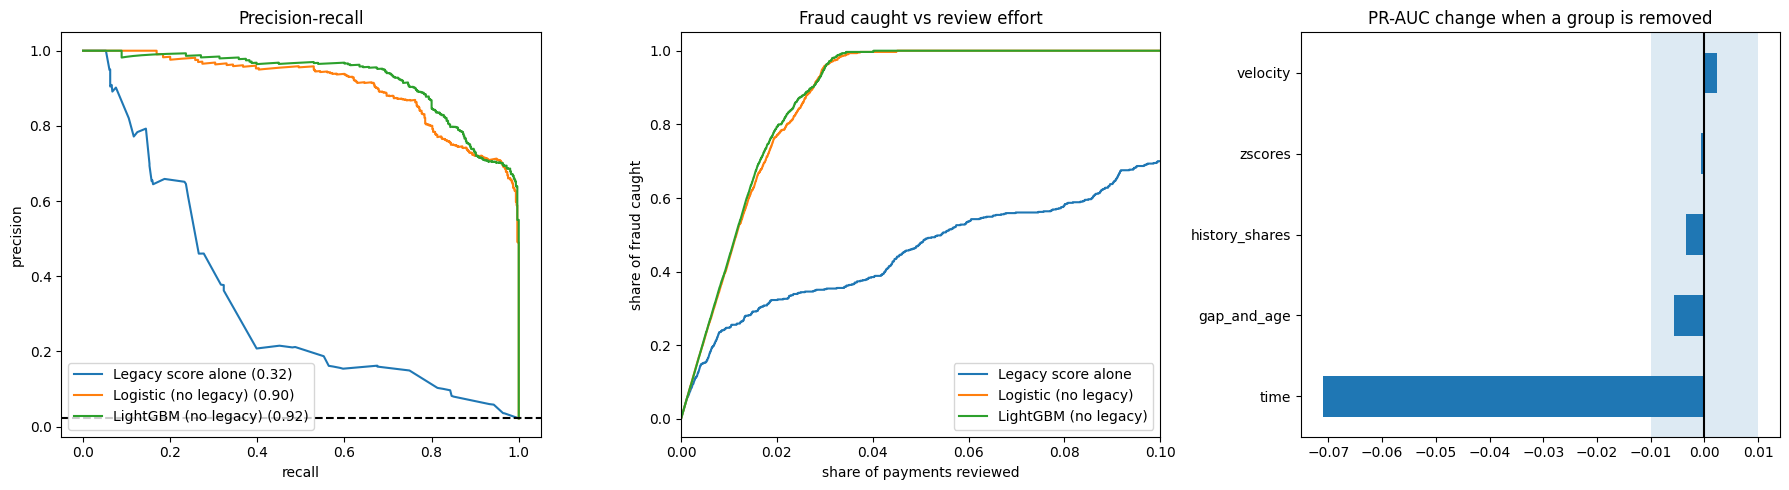

In [363]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. precision-recall curves (dashed line = random guess)
for name, p in scores.items():
    pr, rc, _ = precision_recall_curve(yv, p)
    ax[0].plot(rc, pr, label=f"{name} ({res.loc[name, 'pr_auc']:.2f})")
ax[0].axhline(yv.mean(), ls="--", c="k")
ax[0].set(xlabel="recall", ylabel="precision", title="Precision-recall"); ax[0].legend()

# 2. how much fraud is caught for how much review effort
for name, p in scores.items():
    order = np.argsort(-p)
    ax[1].plot(np.arange(1, len(yv) + 1) / len(yv), np.cumsum(yv[order]) / yv.sum(), label=name)
ax[1].set(xlim=(0, 0.10), xlabel="share of payments reviewed", ylabel="share of fraud caught",
          title="Fraud caught vs review effort"); ax[1].legend()

# 3. ablation: change in PR-AUC when a feature group is removed
full_pr = 0.924
abl = pd.Series({"velocity": 0.9263, "gap_and_age": 0.9183, "zscores": 0.9234,
                 "history_shares": 0.9206, "time": 0.8529})
(abl - full_pr).sort_values().plot.barh(ax=ax[2], title="PR-AUC change when a group is removed")
ax[2].axvline(0, c="k"); ax[2].axvspan(-0.01, 0.01, alpha=0.15)      # rough "noise" band
plt.tight_layout(); plt.show()

In [364]:
def business_table(y, p, amount, rates=(0.01, 0.02, 0.03, 0.05), per=10_000, review_cost=2_000):
    y, p, amount = map(np.asarray, (y, p, amount))
    order = np.argsort(-p); n = len(y); s = per / n
    rows = []
    for r in rates:
        k = int(n * r); top = order[:k]; caught = y[top].sum()
        missed_amt = amount[y == 1].sum() - amount[top][y[top] == 1].sum()
        rows.append({"review rate": r, "reviewed": k * s, "frauds caught": caught * s,
                     "false alarms": (k - caught) * s, "frauds missed": (y.sum() - caught) * s,
                     "fraud naira missed": missed_amt * s, "total cost": missed_amt * s + k * s * review_cost})
    return pd.DataFrame(rows).round(0)

av = np.expm1(val_df["log_amount_ngn"]).to_numpy()      # recovers the naira amount even if you dropped the column
business_table(yv, scores["LightGBM (no legacy)"], av)

,review rate,reviewed,frauds caught,false alarms,frauds missed,fraud naira missed,total cost
0,0.0,100.0,96.0,3.0,125.0,13255577.0,13454867.0
1,0.0,200.0,175.0,24.0,46.0,3639986.0,4039291.0
2,0.0,300.0,211.0,89.0,11.0,733315.0,1332633.0
3,0.0,500.0,221.0,279.0,0.0,0.0,999348.0


## Conclusion

**Goal:** detect fraudulent merchant transactions in a synthetic Nigerian payments dataset, using only information available at payment time. This is transaction-level detection, split out-of-time, with point-in-time features.

| Validation block | PR-AUC | Precision (review top 2%) | Recall (review top 2%) |
|---|---|---|---|
| Legacy score alone | 0.32 | 36% | 32% |
| Logistic regression (no legacy) | 0.76 | 72% | 65% |
| **LightGBM (no legacy)** | **0.92** | **88%** | **79%** |

Random guessing scores about 0.02 PR-AUC, because fraud is about 2% of payments.

**What I found**
- The engineered features beat the legacy score by a wide margin, and trees beat the linear model.
- The legacy score adds nothing once the other features are in (PR-AUC 0.9240 without it, 0.9236 with it), so the model can ship without that dependency.
- Class weights lowered PR-AUC (0.924 to 0.904), so the final model is unweighted.
- Hour of day matters most. Removing the time features cost 0.07 PR-AUC. Removing any other single feature group changed it by less than 0.01.
- `dispute_outcome` is post-hoc, so it was excluded from the model.

**Business view** (per 10,000 payments, about 221 of them fraud; review cost assumed at ₦2,000)

| Payments reviewed | Frauds caught | False alarms | Frauds missed |
|---|---|---|---|
| 1% | 96 | 3 | 125 |
| 2% | 175 | 24 | 46 |
| 3% | 211 | 89 | 11 |
| 5% | 221 | 279 | 0 |

At the chosen threshold (0.01), expected cost on the validation block fell from ₦125.7M (no model) to ₦2.4M. On the test block, no fraud merchant went unflagged, and the first fraudulent payment was usually the one flagged (median delay 0 hours).

**Limitations**
- The data is synthetic with strong built-in signals: night-time fraud, bursts, and fraud merchants that disappear within 21 days. Absolute scores are optimistic, and the value here is the method and the relative comparisons.
- The threshold and the naira savings depend on assumed costs, with no customer-friction cost included. Read them as a demonstration, not a real-world estimate.
- The table above is from the validation block, which was also used for early stopping and for choosing the threshold.